In [1]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import os
from dataclasses import replace
from IPython.display import clear_output
from astropy.stats import mad_std
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.spatial import cKDTree
from astropy.table import Table
from scipy.ndimage import median_filter
from scipy.ndimage import gaussian_filter1d
from astropy.stats import biweight_location
from tqdm import tqdm
import pandas as pd

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import (run_extract, run_stack, read_galaxy_fits, measure, plotting, analysis, multicat,
core, PipelineConfig, stack, selection, masking, extract, optimize)
from utils_lya_halo.io import read_galaxy_fits, apply_finite_cut
from utils_lya_halo.measure import measure_all_bins, integrated_line_flux
from utils_lya_halo.stack import build_stacks
from utils_lya_halo.validation import DEFAULT_UV_LINES

%matplotlib inline

LYA_REST = PipelineConfig.LYA_REST

import warnings
from astropy.utils.exceptions import AstropyUserWarning

warnings.filterwarnings(
    "ignore",
    message="Input data contains invalid values.*",
    category=AstropyUserWarning,
)

# Reading in Outputs and Stacking

In [2]:
catalog_path = "catalogs/lya_halo_catalog_cuts/lya_mosdef_catalog_KEEP.fits"
catalog  = Table.read(catalog_path, format='fits')
catalog[:5]

INDEX,FIELD,CATALOG,ID,ID_V21,ID_V41,MASKNAME,SLITOBJNAME,RA,DEC,z,Z_QUAL,HA_FLUX,HA_FLUX_ERR,HA_FWHM,HA_FWHM_ERR,HB_FLUX,HB_FLUX_ERR,HB_FWHM,HB_FWHM_ERR,HG_FLUX,HG_FLUX_ERR,HG_FWHM,HG_FWHM_ERR,HD_FLUX,HD_FLUX_ERR,HD_FWHM,HD_FWHM_ERR,OII3727_FLUX,OII3727_FLUX_ERR,OII3727_FWHM,OII3727_FWHM_ERR,OII3730_FLUX,OII3730_FLUX_ERR,OII3730_FWHM,OII3730_FWHM_ERR,OIII4364_FLUX,OIII4364_FLUX_ERR,OIII4364_FWHM,OIII4364_FWHM_ERR,OIII4960_FLUX,OIII4960_FLUX_ERR,OIII4960_FWHM,OIII4960_FWHM_ERR,OIII5008_FLUX,OIII5008_FLUX_ERR,OIII5008_FWHM,OIII5008_FWHM_ERR,OI6302_FLUX,OI6302_FLUX_ERR,OI6302_FWHM,OI6302_FWHM_ERR,NII6550_FLUX,NII6550_FLUX_ERR,NII6550_FWHM,NII6550_FWHM_ERR,NII6585_FLUX,NII6585_FLUX_ERR,NII6585_FWHM,NII6585_FWHM_ERR,SII6718_FLUX,SII6718_FLUX_ERR,SII6718_FWHM,SII6718_FWHM_ERR,SII6733_FLUX,SII6733_FLUX_ERR,SII6733_FWHM,SII6733_FWHM_ERR,NEIII3870_FLUX,NEIII3870_FLUX_ERR,NEIII3870_FWHM,NEIII3870_FWHM_ERR,NEIII3969_FLUX,NEIII3969_FLUX_ERR,NEIII3969_FWHM,NEIII3969_FWHM_ERR,NIIHA,NIIHA_ERR,MASS_50,MASS_16,MASS_84,SFR_50,SFR_16,SFR_84,SSFR_50,SSFR_16,SSFR_84,AV_50,AV_16,AV_84,AGE_50,AGE_16,AGE_84,TAU_50,TAU_16,TAU_84,CHI2,ZFAST,EBV_STAR_16,EBV_STAR_50,EBV_STAR_84,HA_SN,HA_FLAG,HB_SN,HB_FLAG,HG_SN,HG_FLAG,HD_SN,HD_FLAG,OII3727_SN,OII3727_FLAG,OII3730_SN,OII3730_FLAG,OIII4364_SN,OIII4364_FLAG,OIII4960_SN,OIII4960_FLAG,OIII5008_SN,OIII5008_FLAG,OI6302_SN,OI6302_FLAG,NII6550_SN,NII6550_FLAG,NII6585_SN,NII6585_FLAG,SII6718_SN,SII6718_FLAG,SII6733_SN,SII6733_FLAG,NEIII3870_SN,NEIII3870_FLAG,NEIII3969_SN,NEIII3969_FLAG,O3,O3_ERR,O32,O32_ERR,EBV_NEB_16,EBV_NEB_50,EBV_NEB_84,FLUX_RADIUS,A_IMAGE,B_IMAGE,THETA_J2000,KRON_RADIUS,FWHM_IMAGE,CLASS_STAR,F_F160W,E_F160W,F_F814W,E_F814W,F_F606W,E_F606W,F_G,E_G,F_R,E_R,F_V,E_V,F_IRAC1,E_IRAC1,IRAC1_CONTAM,F_IRAC2,E_IRAC2,IRAC2_CONTAM,F_IRAC3,E_IRAC3,IRAC3_CONTAM,F_IRAC4,E_IRAC4,IRAC4_CONTAM,USE_PHOT,STAR_FLAG,PHOT_FLAGS,Z_SPEC,TOT_COR,SKELTON_MATCH,BA,INCL_DEG,GALFIT_FLAG_F160W,GALFIT_MAG_F160W,GALFIT_MAG_ERR_F160W,RE_F160W,RE_ERR_F160W,N_F160W,N_ERR_F160W,Q_F160W,Q_ERR_F160W,PA_F160W,PA_ERR_F160W,SN_F160W,VDW_MATCH_F160W,GALFIT_FLAG_F125W,GALFIT_MAG_F125W,GALFIT_MAG_ERR_F125W,RE_F125W,RE_ERR_F125W,N_F125W,N_ERR_F125W,Q_F125W,Q_ERR_F125W,PA_F125W,PA_ERR_F125W,SN_F125W,VDW_MATCH_F125W,RE_BEST,RE_BEST_SRC,Q_BEST,Q_BEST_SRC,RE_CIRC_BEST,MAG_G,MAG_R,MAG_V,MAG_F606W,MAG_F814W,MAG_F160W,GR_COLOR,Z_SECURE,Z_INWINDOW,BEST_LINE_SN,LINE_SN_OK,COORDS_OK,SAMPLE,HAS_DUP_0p5AS,DUP_DROP,BLEND_DROP,BLEND_MERGE,KEEP,XRAY_MATCH,XRAY_SEP_AS,XRAY_NAME,XRAY_FLUX_B,XRAY_SIG,AGN_XRAY,NIIHA_OK,BPT_O3HB,BPT_N2HA,AGN_OPT_USABLE,AGN_OPT,DONLEY_X,DONLEY_Y,AGN_IR_USABLE,AGN_IR,AGN_FLAG,CLEAN,MEX_O3HB,AGN_MEX,MEX_INTERMED,AGN_MEX_USABLE,AGN_MEX_APPLIED,VALID,EBV
int64,bytes6,bytes6,int64,int64,int64,bytes8,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,f

In [3]:
# ---------------------------------------------------------------- INPUTS
random_seed     = 10
bin_mode        = 'kpc'
bins            = [0, 10, 20, 30, 50, 80, 140, 300, 600, 1000, 2000]
field           = 'BOTH'

half_width      = 3.5            # +/- Angstrom around LYA_REST used as the "line" (Stage 3)
vr_approx       = 90             # rough |v| scale (km/s) -- not consumed in this cell;
                                # handy later e.g. plot_centroid_profile(..., ylims=(-3*vr_approx, 3*vr_approx))
stack_method    = 'biweight'
mask_method     = "segmap"

id_col          = "ID"

bg_inner_arcsec = 55.0
bg_outer_arcsec = 65.0

rest_wave_min   = 1100
rest_wave_max   = 1700
spexlim         = (rest_wave_min, rest_wave_max)

n_bootstrap     = 1000
np.random.seed(random_seed)    # reproducibility for anything you resample by hand below

# ---------------------------------------------------------------- CONFIG (drives everything below)
cfg_old = replace(cfg,
    field=field,
    bin_mode=bin_mode,
    bins=[0, 10, 20, 50, 100, 200, 500, 1000, 2000],
    mask_method='image',
    bg_inner_arcsec=57,
    bg_outer_arcsec=63,
    rest_wave_min=rest_wave_min,
    rest_wave_max=rest_wave_max,
    flux_unit="raw",
    rest_density=False,  
    n_bootstrap=n_bootstrap,
    line_window=[LYA_REST - half_width, LYA_REST + half_width])

cfg_new = replace(cfg,
    field=field,
    bin_mode=bin_mode,
    bins=bins,
    mask_method=mask_method,
    bg_inner_arcsec=bg_inner_arcsec,
    bg_outer_arcsec=bg_outer_arcsec,
    rest_wave_min=rest_wave_min,
    rest_wave_max=rest_wave_max,
    flux_unit="raw",
    rest_density=False,  
    n_bootstrap=n_bootstrap,
    line_window=[LYA_REST - half_width, LYA_REST + half_width])

cfg_test = replace(cfg,
    field='COSMOS',
    bin_mode=bin_mode,
    bins=bins,
    mask_method=mask_method,
    bg_inner_arcsec=bg_inner_arcsec,
    bg_outer_arcsec=bg_outer_arcsec,
    rest_wave_min=rest_wave_min,
    rest_wave_max=rest_wave_max,
    flux_unit="raw",
    rest_density=False,  
    n_bootstrap=n_bootstrap,
    line_window=[LYA_REST - half_width, LYA_REST + half_width])

# ---------------------------------------------------------------- FILE PATHS
# one dict keyed by bin_mode -- add a new bin_mode by adding a key, no new elif

#BOTH fields; ALL sources; 25A Interp-Gaussian, Segmap, 55-65"
PRODUCT_PATHS_NEW = {
    'kpc': {
        'AEGIS':  './galaxy_cat65a007_b10_ec8c16_AEGIS_MOSDEF_kpc_biweight_segmap_bg55-65.fits',
        'COSMOS': './galaxy_cat65a007_b10_ec8c16_COSMOS_MOSDEF_kpc_biweight_segmap_bg55-65.fits',
    },
}
#BOTH fields; ALL old sources; [200, 20, 300] Adaptive, 90 Percentile, 57-63"
PRODUCT_PATHS_OLD = {
    'kpc': {
        'AEGIS':  './outputs/galaxy_catc1488c_b8_87bd55_AEGIS_MOSDEF_kpc_biweight_image_bg57-63.fits',
        'COSMOS': './outputs/galaxy_catc1488c_b8_87bd55_COSMOS_MOSDEF_kpc_biweight_image_bg57-63.fits',
    },
}
#COSMOS; 50 sources; 100A Interp-Gaussian, Segmap, 55-65"
PRODUCT_PATHS_C50_100G_S5565 = {
    'kpc': {
        'COSMOS': './outputs/C50_100G_S_55-65.fits',
    },
}
#COSMOS; 50 sources; [200, 20, 300] Adaptive, Segmap, 55-65"
PRODUCT_PATHS_C50_200A_S5565 = {
    'kpc': {
        'COSMOS': './outputs/C50_200A_S_55-65.fits',
    },
}
#COSMOS; 50 sources; [200, 20, 300] Adaptive, Image, 55-65"
PRODUCT_PATHS_C50_200A_I5565 = {
    'kpc': {
        'COSMOS': './outputs/C50_200A_I_55-65.fits',
    },
}
#COSMOS; 50 sources; 100A Interp-Gaussian, Segmap, 100-105"
PRODUCT_PATHS_C50_100G_S100105 = {
    'kpc': {
        'COSMOS': './outputs/C50_100G_S_100-105.fits',
    },
}
#COSMOS; 50 sources; 100A Interp-Gaussian, Segmap, 20-30"
PRODUCT_PATHS_C50_100G_S2030 = {
    'kpc': {
        'COSMOS': './outputs/C50_100G_S_20-30.fits',
    },
}
#COSMOS; 50 sources; 100A Interp-Gaussian, Segmap, 55-65", gal-bg (no per-exposure)
PRODUCT_PATHS_C50_100G_S5565_galbg = {
    'kpc': {
        'COSMOS': './outputs/C50_100G_S_55-65_gal-bg.fits',
    },
}
#COSMOS; 50 sources; 100A Interp-Gaussian, Segmap-Global, 55-65", gal-bg (no per-exposure)
PRODUCT_PATHS_C50_100G_SG_5565_galbg = {
    'kpc': {
        'COSMOS': './outputs/C50_100G_SG_55-65_gal-bg.fits',
    },
}
#COSMOS; 50 sources; 100A Interp-Gaussian, Segmap-Local, 55-65", gal-bg (no per-exposure)
PRODUCT_PATHS_C50_100G_SL_5565_galbg = {
    'kpc': {
        'COSMOS': './outputs/C50_100G_SL_55-65_gal-bg.fits',
    },
}
#COSMOS; 50 sources; 100A Interp-Gaussian, Segmap-Global, 55-65"
PRODUCT_PATHS_C50_100G_SG_5565 = {
    'kpc': {
        'COSMOS': './outputs/C50_100G_SG_55-65.fits',
    },
}
#COSMOS; 50 sources; 100A Interp-Gaussian, Segmap-Local, 55-65"
PRODUCT_PATHS_C50_100G_SL_5565 = {
    'kpc': {
        'COSMOS': './outputs/C50_100G_SL_55-65.fits',
    },
}

In [4]:
# ============================================================================
# OLD PRODUCT
paths = PRODUCT_PATHS_OLD[bin_mode.lower()]

products_old = {
    label: apply_finite_cut(
        read_galaxy_fits(path),
        cfg_old.cut_radial_bin,
        cfg_old.min_good_wave,
    )
    for label, path in paths.items()
}
product1_old = products_old["AEGIS"]
product2_old = products_old["COSMOS"]

mega_old = multicat.combine_products(products_old, label_col="SUBSET")

# ============================================================================
# NEW PRODUCT
paths = PRODUCT_PATHS_NEW[bin_mode.lower()]

products_new = {
    label: apply_finite_cut(
        read_galaxy_fits(path),
        cfg_new.cut_radial_bin,
        cfg_new.min_good_wave,
    )
    for label, path in paths.items()
}
product1_new = products_new["AEGIS"]
product2_new = products_new["COSMOS"]

mega_new = multicat.combine_products(products_new, label_col="SUBSET")

# ============================================================================
# COSMOS 50 GALAXIES (100A Gaussian) - Segmap
paths = PRODUCT_PATHS_C50_100G_S5565[bin_mode.lower()]

products_test1 = {
    label: apply_finite_cut(
        read_galaxy_fits(path),
        cfg_test.cut_radial_bin,
        cfg_test.min_good_wave,
    )
    for label, path in paths.items()
}

product_test1 = products_test1["COSMOS"]

# ============================================================================
# COSMOS 50 GALAXIES (100A Adaptive) - Segmap
paths = PRODUCT_PATHS_C50_200A_S5565[bin_mode.lower()]

products_test2 = {
    label: apply_finite_cut(
        read_galaxy_fits(path),
        cfg_test.cut_radial_bin,
        cfg_test.min_good_wave,
    )
    for label, path in paths.items()
}

product_test2 = products_test2["COSMOS"]

# ============================================================================
# COSMOS 50 GALAXIES (200A Adaptive) - Image
paths = PRODUCT_PATHS_C50_200A_I5565[bin_mode.lower()]

products_test3 = {
    label: apply_finite_cut(
        read_galaxy_fits(path),
        cfg_test.cut_radial_bin,
        cfg_test.min_good_wave,
    )
    for label, path in paths.items()
}

product_test3 = products_test3["COSMOS"]

# ============================================================================
# COSMOS 50 GALAXIES (100A Gaussian) - Segmap - 100-105
paths = PRODUCT_PATHS_C50_100G_S100105[bin_mode.lower()]

products_test4 = {
    label: apply_finite_cut(
        read_galaxy_fits(path),
        cfg_test.cut_radial_bin,
        cfg_test.min_good_wave,
    )
    for label, path in paths.items()
}

product_test4 = products_test4["COSMOS"]

# ============================================================================
# COSMOS 50 GALAXIES (100A Gaussian) - Segmap - 20-30
paths = PRODUCT_PATHS_C50_100G_S2030[bin_mode.lower()]

products_test5 = {
    label: apply_finite_cut(
        read_galaxy_fits(path),
        cfg_test.cut_radial_bin,
        cfg_test.min_good_wave,
    )
    for label, path in paths.items()
}

product_test5 = products_test5["COSMOS"]

# ============================================================================
# COSMOS 50 GALAXIES (100A Gaussian) - Segmap - 55-65 - galbg
paths = PRODUCT_PATHS_C50_100G_S5565_galbg[bin_mode.lower()]

products_test6 = {
    label: apply_finite_cut(
        read_galaxy_fits(path),
        cfg_test.cut_radial_bin,
        cfg_test.min_good_wave,
    )
    for label, path in paths.items()
}

product_test6 = products_test6["COSMOS"]

# ============================================================================
# COSMOS 50 GALAXIES (100A Gaussian) - Segmap+SpecGlobal - 55-65 - galbg
paths = PRODUCT_PATHS_C50_100G_SG_5565_galbg[bin_mode.lower()]

products_test7 = {
    label: apply_finite_cut(
        read_galaxy_fits(path),
        cfg_test.cut_radial_bin,
        cfg_test.min_good_wave,
    )
    for label, path in paths.items()
}

product_test7 = products_test7["COSMOS"]

# ============================================================================
# COSMOS 50 GALAXIES (100A Gaussian) - Segmap+SpecLocal - 55-65 - galbg
paths = PRODUCT_PATHS_C50_100G_SL_5565_galbg[bin_mode.lower()]

products_test8 = {
    label: apply_finite_cut(
        read_galaxy_fits(path),
        cfg_test.cut_radial_bin,
        cfg_test.min_good_wave,
    )
    for label, path in paths.items()
}

product_test8 = products_test8["COSMOS"]

# ============================================================================
# COSMOS 50 GALAXIES (100A Gaussian) - Segmap+SpecGlobal - 55-65
paths = PRODUCT_PATHS_C50_100G_SG_5565[bin_mode.lower()]

products_test9 = {
    label: apply_finite_cut(
        read_galaxy_fits(path),
        cfg_test.cut_radial_bin,
        cfg_test.min_good_wave,
    )
    for label, path in paths.items()
}

product_test9 = products_test9["COSMOS"]

# ============================================================================
# COSMOS 50 GALAXIES (100A Gaussian) - Segmap+SpecLocal - 55-65
paths = PRODUCT_PATHS_C50_100G_SL_5565[bin_mode.lower()]

products_test10 = {
    label: apply_finite_cut(
        read_galaxy_fits(path),
        cfg_test.cut_radial_bin,
        cfg_test.min_good_wave,
    )
    for label, path in paths.items()
}

product_test10 = products_test10["COSMOS"]

Finite-spectrum cut (bin 7, > 100 px): kept 230 / 248 galaxies
Finite-spectrum cut (bin 7, > 100 px): kept 276 / 280 galaxies
combined 2 products -> 506 galaxies (origin in column 'SUBSET')
Finite-spectrum cut (bin 9, > 100 px): kept 227 / 244 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 275 / 278 galaxies
combined 2 products -> 502 galaxies (origin in column 'SUBSET')
Finite-spectrum cut (bin 9, > 100 px): kept 50 / 50 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 50 / 50 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 50 / 50 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 50 / 50 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 50 / 50 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 50 / 50 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 50 / 50 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 50 / 50 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 50 / 50 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 50 / 50 galaxies


In [5]:
def match_products(products, anchor=None, radius_arcsec=1.0,
                   ra_col="RA", dec_col="DEC", verbose=True):
    """
    Restrict several GalaxyProducts to the galaxies they ALL share, matched by
    sky position (for when some catalogs lack a common ID column). Every returned
    product holds the SAME galaxies in the SAME order, so stacks built from them
    differ only by extraction method -- a controlled comparison.

    products : dict {label: GalaxyProduct}
    anchor   : label defining the common ordering. Default = fewest-galaxy product
               (natural limiting set; anchoring on a COSMOS-only test auto-restricts
               the mega products to COSMOS).
    radius_arcsec : match tolerance; keep small-but-nonzero even if coords 'line up'.

    Returns dict: products {label: sliced}, n_common, anchor,
                  sep {label: (n_common,) arcsec}, dropped {label: int}.
    """
    labels = list(products)
    if anchor is None:
        anchor = min(labels, key=lambda L: products[L].ngal)
    A = products[anchor]

    idx = {anchor: np.arange(A.ngal)}
    sep = {anchor: np.zeros(A.ngal)}
    ok  = np.ones(A.ngal, bool)
    for L in labels:
        if L == anchor:
            continue
        j, s, m = multicat.match_catalog(A, products[L].catalog, radius_arcsec=radius_arcsec,
                                ra_col=ra_col, dec_col=dec_col, verbose=False)
        idx[L], sep[L] = j, s
        ok &= m                                   # require a match in every product

    for L in labels:                              # resolve rare collisions: keep closer
        if L == anchor:
            continue
        seen = {}
        for a in np.flatnonzero(ok):
            t = int(idx[L][a])
            if t in seen:
                worse = a if sep[L][a] >= sep[L][seen[t]] else seen[t]
                ok[worse] = False
                if worse != a:
                    seen[t] = a
            else:
                seen[t] = a

    common = np.flatnonzero(ok)
    out, sep_out = {}, {}
    for L in labels:
        sel = common if L == anchor else idx[L][common]
        out[L] = selection.slice_product(products[L], sel)
        sep_out[L] = sep[L][common]

    if verbose:
        print(f"match_products: anchor='{anchor}', common={common.size} "
              f"(radius {radius_arcsec:g}\")")
        for L in labels:
            print(f"    {L:<8} {products[L].ngal:>4} -> {out[L].ngal:>4}  "
                  f"(dropped {products[L].ngal - out[L].ngal})")
    return {"products": out, "n_common": int(common.size), "anchor": anchor,
            "sep": sep_out,
            "dropped": {L: int(products[L].ngal - out[L].ngal) for L in labels}}

In [6]:
def decompose_bg_offset(bd, fit_range=(1250., 1600.),
                        line_rest=1215.67, line_halfwidth=30.):
    """
    Split the stacked (new-old) background footprint from stack_bg_difference()
    into the three pieces that map to the three changes you made:
      dc         : uniform level offset  -> masking / 'subtraction size'
      slope      : linear tilt per A      -> throughput / mean-SED effect
      wiggle_rms : scatter left after removing dc+slope -> filter WIDTH over-fit
    Weighted (1/sem^2) linear fit over fit_range, with the Lya line region masked.
    """
    rest, med, sem = bd["rest"], bd["med"], bd["sem"]
    m = ((rest >= fit_range[0]) & (rest <= fit_range[1])
         & np.isfinite(med) & np.isfinite(sem) & (sem > 0)
         & (np.abs(rest - line_rest) > line_halfwidth))
    x, y, sw = rest[m], med[m], 1.0 / sem[m]
    x0 = np.median(x)
    A = np.vstack([np.ones_like(x), (x - x0)]).T
    (dc, slope), *_ = np.linalg.lstsq(A * sw[:, None], y * sw, rcond=None)
    resid = y - (dc + slope * (x - x0))
    wiggle_rms = float(np.sqrt(np.average(resid**2, weights=sw**2)))
    return {"dc": float(dc), "slope_per_A": float(slope), "x0": float(x0),
            "wiggle_rms": wiggle_rms, "mask": m,
            "dc_to_wiggle": float(abs(dc) / wiggle_rms) if wiggle_rms else np.inf}

def _bg_diff_aligned(prod, ref, z_col="z"):
    """(prod - ref) background for products already aligned by match_products."""
    if prod.background is None or ref.background is None:
        raise ValueError("both products need a BACKGROUND HDU (background is None)")
    if prod.background.shape != ref.background.shape:
        raise ValueError(f"bg shape mismatch {prod.background.shape} vs {ref.background.shape}; "
                         "match_products first so galaxies/order line up")
    return {"dbg": np.asarray(prod.background, float) - np.asarray(ref.background, float),
            "wave": np.asarray(getattr(prod.wave, "value", prod.wave), float),
            "z":    np.asarray(prod.catalog[z_col], float)}

def background_offset_table(matched_products, ref, z_col="z", rest_range=(1150., 1650.)):
    """
    For aligned products, split each run's background offset vs `ref` into:
      dc          -> MASKING / ANNULUS  (shared level shift; filter can't make this)
      slope_per_A -> throughput / SED tilt
      wiggle_rms  -> FILTER width/technique
    Reuses stack_bg_difference() + decompose_bg_offset() from earlier turns.

    DC ~constant across runs with different filters  => offset is masking/annulus.
    wiggle_rms ordered by filter width               => filter drives the wiggle.
    """
    ref_p = matched_products[ref]
    rows = {}
    for L, p in matched_products.items():
        if L == ref:
            continue
        bd  = stack_bg_difference(_bg_diff_aligned(p, ref_p, z_col), rest_range=rest_range)
        dec = decompose_bg_offset(bd)
        rows[L] = {"dc": dec["dc"], "slope_per_A": dec["slope_per_A"],
                   "wiggle_rms": dec["wiggle_rms"], "dc_over_wiggle": dec["dc_to_wiggle"]}
    return rows


def bg_residual_metrics(stack_result, bins, cont_window=(1350., 1600.), method="biweight"):
    """
    Per-bin background-residual metrics from a build_stacks() result (keep_cube=True).
    Keyed by (edge_lo, edge_hi) so two runs with DIFFERENT bin counts can be matched
    by radius. All metrics use robust (median/mad_std) statistics, so the tall
    bad-pixel spikes don't inflate them.
      bias        : median of the robust stacked spectrum over cont_window (offset from 0)
      rms         : mad_std of that spectrum (wavelength-direction residual structure)
      combined    : hypot(bias, rms)  -- total robust residual amplitude
      gal_scatter : mad_std across galaxies of each galaxy's continuum-window median
    """
    cf = np.asarray(stack_result["cube_flux"])      # (ngal, nrad, nwave)
    ce = np.asarray(stack_result["cube_err"])
    rw = np.asarray(stack_result["rest_wave"])
    stk = np.asarray(stack_result["stacks"][method]["flux"])   # (nrad, nwave)
    win = (rw >= cont_window[0]) & (rw <= cont_window[1])
    bins = np.asarray(bins, float)

    out = {}
    for r in range(len(bins) - 1):
        key = (round(float(bins[r]), 3), round(float(bins[r + 1]), 3))
        fw = stk[r][win]
        bias = float(np.nanmedian(fw))
        rms  = float(mad_std(fw, ignore_nan=True))

        fg = np.nanmedian(cf[:, r, :][:, win], axis=1)          # per-galaxy residual
        eg = np.nanmedian(ce[:, r, :][:, win], axis=1)
        wg = np.where(np.isfinite(eg) & (eg > 0), 1.0 / eg**2, 0.0)
        g  = np.isfinite(fg)
        out[key] = dict(
            bias=bias, rms=rms, combined=float(np.hypot(bias, rms)),
            gal_scatter=float(mad_std(fg[g])) if g.any() else np.nan,
            med=float(np.nanmedian(fg[g])) if g.any() else np.nan,
            invvar=float(np.nansum(fg[g]*wg[g]) / np.nansum(wg[g])) if np.nansum(wg[g]) > 0 else np.nan,
            ngal=int(g.sum()),
        )
    return out


def compare_bg_runs(old, new, label_old="old", label_new="new"):
    """Print edge-matched bins side by side. ratio < 1 => new run is tighter."""
    keys = sorted(k for k in new if k in old)
    hdr = f"{'bin(kpc)':>12} {'comb_'+label_old:>12} {'comb_'+label_new:>12} {'r':>6}   " \
          f"{'gsc_'+label_old:>12} {'gsc_'+label_new:>12} {'r':>6}"
    print(hdr); print("-" * len(hdr))
    for k in keys:
        o, n = old[k], new[k]
        cr = n["combined"]/o["combined"] if o["combined"] else np.nan
        gr = n["gal_scatter"]/o["gal_scatter"] if o["gal_scatter"] else np.nan
        print(f"{k[0]:>5.0f}-{k[1]:<6.0f} {o['combined']:>12.3e} {n['combined']:>12.3e} {cr:>6.2f}   "
              f"{o['gal_scatter']:>12.3e} {n['gal_scatter']:>12.3e} {gr:>6.2f}")
    return keys

def match_products_by_coord(prod_a, prod_b, ra_col="RA", dec_col="DEC",
                            tol_arcsec=0.2):
    """
    Row indices aligning two GalaxyProducts by on-sky position (for when the two
    catalogs don't share an ID column). Nearest-neighbor within tol_arcsec, with
    duplicate b-matches resolved to the closest a. RA/DEC in degrees.

    Returns (idx_a, idx_b, sep_arcsec): prod_a.<arr>[idx_a] and prod_b.<arr>[idx_b]
    are the same galaxies in the same order; sep_arcsec is the match separation.
    """
    raa  = np.asarray(prod_a.catalog[ra_col],  float)
    deca = np.asarray(prod_a.catalog[dec_col], float)
    rab  = np.asarray(prod_b.catalog[ra_col],  float)
    decb = np.asarray(prod_b.catalog[dec_col], float)
    ca = SkyCoord(raa * u.deg, deca * u.deg)
    cb = SkyCoord(rab * u.deg, decb * u.deg)

    j, sep, _ = ca.match_to_catalog_sky(cb)          # for each a, nearest b
    sep_as = sep.arcsec
    keep = sep_as <= tol_arcsec

    # resolve any two a's landing on the same b -> keep the closer one
    ia = np.where(keep)[0]
    ib = j[keep]
    s  = sep_as[keep]
    order = np.argsort(s)                            # closest first
    ia, ib, s = ia[order], ib[order], s[order]
    _, first = np.unique(ib, return_index=True)      # first (=closest) per b
    ia, ib, s = ia[first], ib[first], s[first]
    order2 = np.argsort(ia)                          # back to prod_a order
    return ia[order2], ib[order2], s[order2]


def compare_backgrounds(prod_old, prod_new, ra_col="RA", dec_col="DEC",
                        z_col="z", tol_arcsec=0.2, rest_window=(1350., 1600.)):
    """
    Diff the per-galaxy background each run subtracted, matched on sky position.
    The background is OBSERVED-frame, so the rest-frame continuum window is
    redshifted per galaxy: obs_window_i = rest_window * (1 + z_i). No re-extraction.
    """
    ia, ib, sep = match_products_by_coord(prod_old, prod_new, ra_col, dec_col, tol_arcsec)
    if ia.size == 0:
        raise ValueError(f"no galaxies matched within {tol_arcsec}\"")

    bo = np.asarray(prod_old.background, float)[ia]      # (nmatch, nwave) observed
    bn = np.asarray(prod_new.background, float)[ib]
    w  = np.asarray(getattr(prod_old.wave, "value", prod_old.wave), float)   # observed
    if not np.allclose(w, np.asarray(getattr(prod_new.wave, "value", prod_new.wave), float),
                       equal_nan=True):
        raise ValueError("the two runs are on different wave grids; can't diff directly")

    dbg = bn - bo
    z   = np.asarray(prod_old.catalog[z_col], float)[ia]   # matched galaxies

    # per-galaxy median of the bg difference over that galaxy's rest continuum window
    off = np.full(z.size, np.nan)
    n_win = np.zeros(z.size, int)
    for k, zk in enumerate(z):
        if not np.isfinite(zk):
            continue
        lo, hi = rest_window[0] * (1 + zk), rest_window[1] * (1 + zk)
        m = (w >= lo) & (w <= hi)
        n_win[k] = m.sum()
        if m.any():
            off[k] = np.nanmedian(dbg[k, m])

    if n_win.max() == 0:
        raise ValueError(f"rest window {rest_window} never lands on the observed grid "
                         f"[{w.min():.0f},{w.max():.0f}] for any galaxy -- check z_col/units")
    good = np.isfinite(off)
    return {
        "dbg": dbg, "wave": w, "z": z, "sep_arcsec": sep,
        "offset_per_gal": off,
        "offset_med": float(np.nanmedian(off[good])),
        "offset_scatter": float(mad_std(off[good])),
        "n_matched": int(ia.size),
        "median_window_pix": int(np.median(n_win[n_win > 0])),
        "rest_window": rest_window,
    }


def stack_bg_difference(cmp, rest_range=(1150., 1650.), d_rest=1.0):
    """
    Stack the per-galaxy background difference (new - old) into ONE rest-frame
    spectrum, to reveal its SHAPE. `cmp` is the compare_backgrounds() output
    (uses cmp['dbg'] observed-frame, cmp['wave'], cmp['z']).

    Flat line offset from zero  -> pure DC level change (harmless-ish).
    Wiggle across the continuum -> narrow filter over-fitting (the smoking gun).

    Returns dict: rest, med (median diff/pixel), sem (scatter/sqrt N), n (galaxies/pixel).
    """
    dbg = np.asarray(cmp["dbg"], float)          # (ngal, nwave), observed frame
    w   = np.asarray(cmp["wave"], float)
    z   = np.asarray(cmp["z"], float)
    rest = np.arange(rest_range[0], rest_range[1] + d_rest, d_rest)

    resamp = np.full((dbg.shape[0], rest.size), np.nan)
    for i, zi in enumerate(z):
        if not np.isfinite(zi):
            continue
        r_axis = w / (1 + zi)                     # observed -> rest for this galaxy
        g = np.isfinite(dbg[i])
        if g.sum() >= 2:
            resamp[i] = np.interp(rest, r_axis[g], dbg[i][g], left=np.nan, right=np.nan)

    n   = np.sum(np.isfinite(resamp), axis=0)
    med = np.nanmedian(resamp, axis=0)
    sem = mad_std(resamp, axis=0, ignore_nan=True) / np.sqrt(np.maximum(n, 1))
    med[n == 0] = np.nan; sem[n == 0] = np.nan
    return {"rest": rest, "med": med, "sem": sem, "n": n}


def plot_bg_difference_stack(bd, cont_window=(1350., 1600.), lya_rest=1215.67):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.fill_between(bd["rest"], bd["med"] - bd["sem"], bd["med"] + bd["sem"],
                    color="C0", alpha=0.3)
    ax.plot(bd["rest"], bd["med"], color="C0", lw=1.2)
    ax.axhline(0, color="k", lw=0.8)
    ax.axvline(lya_rest, color="magenta", lw=0.8, label="Lyα")
    ax.axvspan(*cont_window, color="0.85", zorder=0, label="continuum window")
    ax.set_xlabel("rest wavelength"); ax.set_ylabel("stacked (new - old) background")
    ax.set_title("Mean footprint of the smoother change"); ax.legend()
    fig.tight_layout()
    return fig


def plot_bg_comparison(old, new, label_old="old", label_new="new"):
    keys = sorted(k for k in new if k in old)
    labels = [f"{k[0]:.0f}-{k[1]:.0f}" for k in keys]
    comb = [new[k]["combined"]/old[k]["combined"] if old[k]["combined"] else np.nan for k in keys]
    gsc  = [new[k]["gal_scatter"]/old[k]["gal_scatter"] if old[k]["gal_scatter"] else np.nan for k in keys]
    x = np.arange(len(keys)); w = 0.38
    fig, ax = plt.subplots(figsize=(1.5*len(keys) + 3, 4))
    ax.bar(x - w/2, comb, w, label="stacked residual (bias⊕rms)")
    ax.bar(x + w/2, gsc,  w, label="galaxy-to-galaxy scatter")
    ax.axhline(1, color="k", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel(f"{label_new} / {label_old}   (<1 = new tighter)")
    ax.set_xlabel("radial bin (kpc)"); ax.legend(); fig.tight_layout()
    return fig

In [7]:
def _boxcar_trend(y, width_pix):
    """NaN-safe smooth trend (boxcar mean) used as the high-pass reference."""
    y = np.asarray(y, float)
    good = np.isfinite(y)
    if not good.any():
        return np.full_like(y, np.nan)
    yf = np.interp(np.arange(y.size), np.flatnonzero(good), y[good])
    k = max(int(width_pix) | 1, 3)                       # force odd, >=3
    ker = np.ones(k) / k
    return np.convolve(np.pad(yf, k // 2, mode="edge"), ker, mode="valid")

def continuum_wiggle_by_bin(stack_result, bins, method="biweight",
                            cont_window=(1250., 1600.), lya_rest=1215.67,
                            lya_halfwidth=25., trend_A=60.):
    """
    Artificial-wiggle amplitude per radial bin: mad_std of the continuum after
    removing a smooth (trend_A-wide) trend and masking Lya. Structure left on
    scales < trend_A is what a good background should NOT contain. Keyed by
    (edge_lo, edge_hi) so runs with different bin counts match by radius.
    Compare the SAME method across runs -- real galaxy signal is identical on
    matched galaxies, so method-to-method wiggle differences are pure background.
    """
    rw  = np.asarray(stack_result["rest_wave"], float)
    stk = np.asarray(stack_result["stacks"][method]["flux"])     # (nrad, nwave)
    bins = np.asarray(bins, float)
    d_rest = np.median(np.diff(rw))
    wpix = max(int(round(trend_A / d_rest)), 3)
    inwin = ((rw >= cont_window[0]) & (rw <= cont_window[1])
             & (np.abs(rw - lya_rest) > lya_halfwidth))
    out = {}
    for r in range(len(bins) - 1):
        resid = stk[r] - _boxcar_trend(stk[r], wpix)
        m = inwin & np.isfinite(resid)
        key = (round(float(bins[r]), 3), round(float(bins[r + 1]), 3))
        out[key] = float(mad_std(resid[m])) if m.sum() > 10 else np.nan
    return out

def plot_wiggle_by_bin(wiggle_dicts, labels):
    """Wiggle amplitude vs radius, one line per run (lower = smoother background)."""
    fig, ax = plt.subplots(figsize=(8, 5))
    for w, lab in zip(wiggle_dicts, labels):
        keys = sorted(w)
        ctr  = [0.5 * (k[0] + k[1]) for k in keys]
        ax.plot(ctr, [w[k] for k in keys], marker="o", label=lab)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("bin center (kpc)"); ax.set_ylabel("continuum wiggle RMS")
    ax.set_title("Artificial continuum structure vs radius")
    ax.legend(); fig.tight_layout()
    return fig

In [8]:
# Bright near-IR/optical OH airglow + O2/Na, air wavelengths (Angstrom). Trimmed to
# the range your grid covers (~3470-5540); extend if your obs grid runs redder.
OH_SKYLINES_A = np.array([
    3650.2, 3933.7, 4046.6, 4358.3, 4861.4, 5015.7, 5199.4, 5460.7, 5577.3,
])

def observed_frame_bg_stack(cmp_or_products, ref=None, z_col="z",
                            obs_range=None, d_obs=None):
    """
    Stack a background (or bg difference) in the OBSERVED frame, where sky lines
    are stationary. Two call styles:
      - pass a compare_backgrounds()-style dict {'dbg','wave','z'}  -> stacks dbg
      - pass (matched_products_dict, ref=label)                    -> stacks each
        product's background minus ref's, per run.
    Returns dict {label: {'obs','med','sem','n'}} (single key 'bg' for the dict form).
    Sky residuals show as spikes fixed in obs wavelength; artificial continuum
    wiggles do NOT sit at OH lines and partly wash out here.
    """
    def _one(dbg, wave, z):
        wave = np.asarray(wave, float)
        lo = obs_range[0] if obs_range else float(np.nanmin(wave))
        hi = obs_range[1] if obs_range else float(np.nanmax(wave))
        step = d_obs if d_obs else float(np.median(np.diff(wave)))
        obs = np.arange(lo, hi + step, step)
        # background is already observed-frame; galaxies share the same obs grid,
        # so this is a straight stack (no per-z shift needed for the bg itself).
        R = np.full((dbg.shape[0], obs.size), np.nan)
        for i in range(dbg.shape[0]):
            g = np.isfinite(dbg[i])
            if g.sum() >= 2:
                R[i] = np.interp(obs, wave[g], dbg[i][g], left=np.nan, right=np.nan)
        n = np.sum(np.isfinite(R), axis=0)
        med = np.nanmedian(R, axis=0)
        sem = mad_std(R, axis=0, ignore_nan=True) / np.sqrt(np.maximum(n, 1))
        med[n == 0] = np.nan; sem[n == 0] = np.nan
        return {"obs": obs, "med": med, "sem": sem, "n": n}

    if isinstance(cmp_or_products, dict) and "dbg" in cmp_or_products:
        c = cmp_or_products
        return {"bg": _one(np.asarray(c["dbg"], float),
                           np.asarray(c["wave"], float), np.asarray(c["z"], float))}

    prods = cmp_or_products
    refp = prods[ref]
    out = {}
    for L, p in prods.items():
        if L == ref:
            continue
        dbg = np.asarray(p.background, float) - np.asarray(refp.background, float)
        out[L] = _one(dbg, np.asarray(getattr(p.wave, "value", p.wave), float),
                      np.asarray(p.catalog[z_col], float))
    return out


def plot_observed_frame_bg(stacks_obs, skylines=OH_SKYLINES_A, band_A=6.0):
    """Overlay observed-frame bg stacks with OH sky-line markers. Spikes ON the
    dashed lines = sky residual; structure BETWEEN them = something else."""
    fig, ax = plt.subplots(figsize=(11, 4))
    for L, s in stacks_obs.items():
        ax.plot(s["obs"], s["med"], lw=0.9, label=L)
    for w in skylines:
        ax.axvspan(w - band_A, w + band_A, color="0.85", zorder=0)
        ax.axvline(w, color="0.6", lw=0.6, ls="--", zorder=0)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("observed wavelength [A]"); ax.set_ylabel("stacked background")
    ax.set_title("Observed-frame background vs OH sky lines"); ax.legend()
    fig.tight_layout()
    return fig

def skyline_power_fraction(s, skylines=OH_SKYLINES_A, band_A=6.0):
    """Fraction of the background residual variance sitting within band_A of an OH
    line. High => wiggles are largely sky residual; low => they're not."""
    obs, med = np.asarray(s["obs"]), np.asarray(s["med"])
    good = np.isfinite(med)
    on = np.zeros_like(obs, bool)
    for w in skylines:
        on |= np.abs(obs - w) <= band_A
    v_on  = np.nansum(med[good & on] ** 2)
    v_all = np.nansum(med[good] ** 2)
    return float(v_on / v_all) if v_all else np.nan

In [9]:
# pass the FULL mega products; anchoring on a 50-source COSMOS test auto-restricts
# everything to those shared COSMOS galaxies (AEGIS won't match a COSMOS anchor).
products = {
    #"old_200A":   mega_old,        # old 200A adaptive, percentile mask
    "new_25G":    mega_new,        # new 25A gaussian, segmap  (the regression)
    "100G":       product_test1,   # test: 100A gaussian, segmap, wide annulus
    "200A":       product_test2,   # test: 200A adaptive, segmap, wide annulus
    "im_200A":    product_test3,   # test: 200A adaptive, image, wide annulus
    "100G_100105":product_test4,   # test: 100A gaussian, segmap, large annulus
    "100G_2030":  product_test5,   # test: 100A gaussian, segmap, large annulus
    "100G_galbg": product_test6,   # test: 100A gaussian, segmap, wide annulus
    "100G_SL_galbg":    product_test7,   # test: 100A gaussian, segmap, large annulus
    "100G_SG_galbg":    product_test8,   # test: 100A gaussian, segmap, wide annulus
    "100G_SL":    product_test9,   # test: 100A gaussian, segmap, large annulus
    "100G_SG":    product_test10,   # test: 100A gaussian, segmap, wide annulus
}
#Gone: "old_200A": cfg_old, 
cfg_for  = {"new_25G": cfg_new, "100G": cfg_test, "200A": cfg_test, "im_200A": cfg_test,
            "100G_100105": cfg_test, "100G_2030": cfg_test, "100G_galbg": cfg_test,
            "100G_SL_galbg": cfg_test, "100G_SG_galbg": cfg_test, "100G_SL": cfg_test, "100G_SG": cfg_test}
bins_for = {L: c.bins for L, c in cfg_for.items()}

M = match_products(products, radius_arcsec=1.0)     # -> ~50 shared COSMOS galaxies
print("worst separation:",
      max(float(np.nanmax(s)) for s in M["sep"].values()), "arcsec")

stacks  = {L: stack.build_stacks(cfg_for[L], p, keep_cube=True)
           for L, p in M["products"].items()}

match_products: anchor='100G', common=50 (radius 1")
    new_25G   502 ->   50  (dropped 452)
    100G       50 ->   50  (dropped 0)
    200A       50 ->   50  (dropped 0)
    im_200A    50 ->   50  (dropped 0)
    100G_100105   50 ->   50  (dropped 0)
    100G_2030   50 ->   50  (dropped 0)
    100G_galbg   50 ->   50  (dropped 0)
    100G_SL_galbg   50 ->   50  (dropped 0)
    100G_SG_galbg   50 ->   50  (dropped 0)
    100G_SL    50 ->   50  (dropped 0)
    100G_SG    50 ->   50  (dropped 0)
worst separation: 0.0 arcsec


# Measuring Spectra

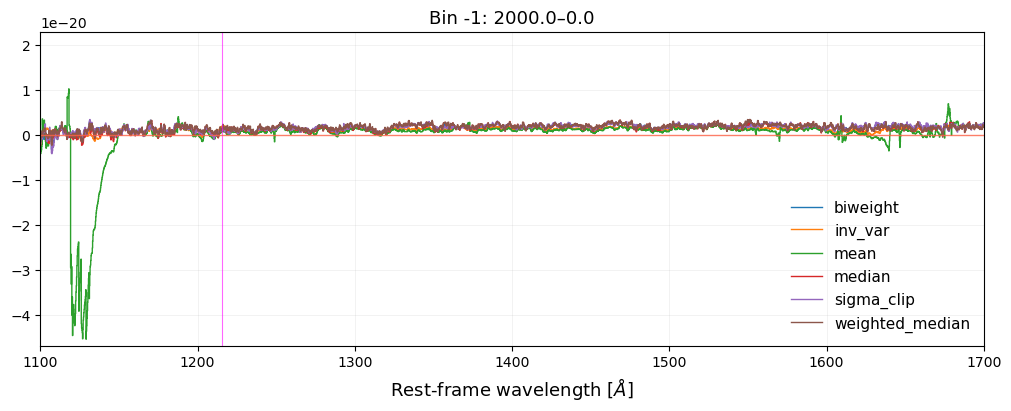

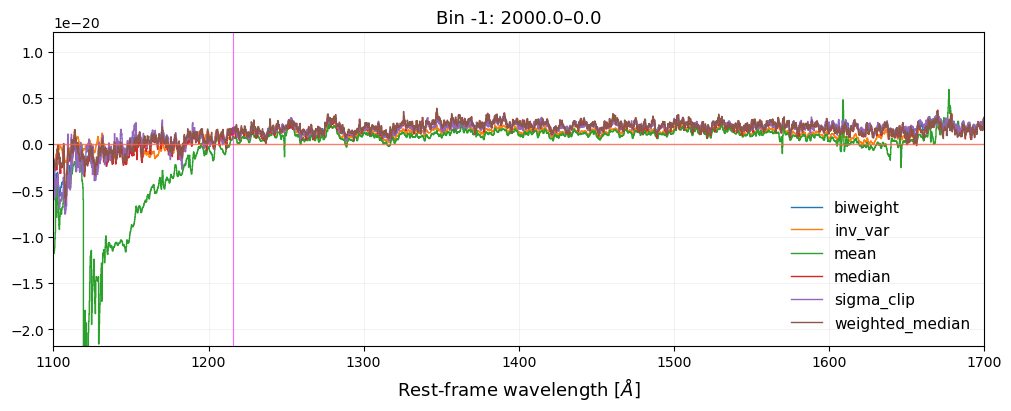

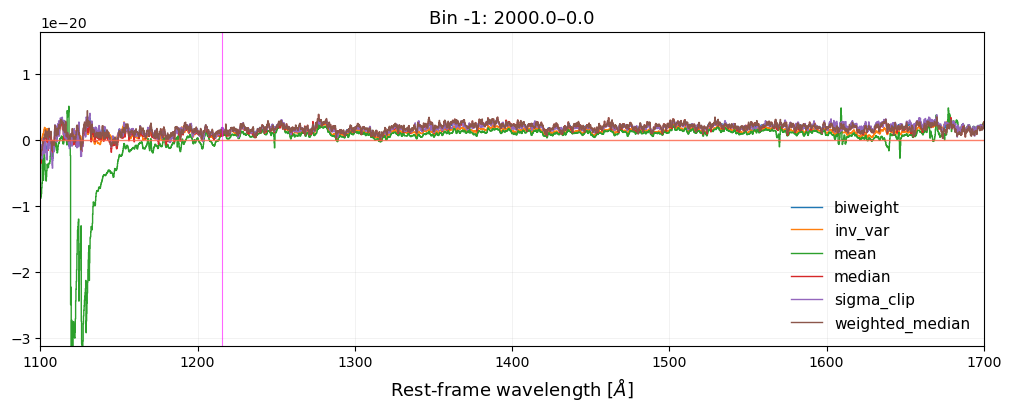

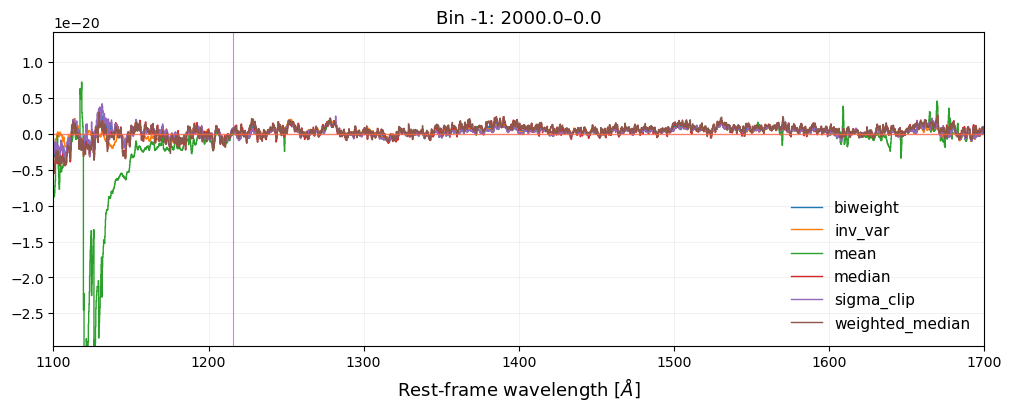

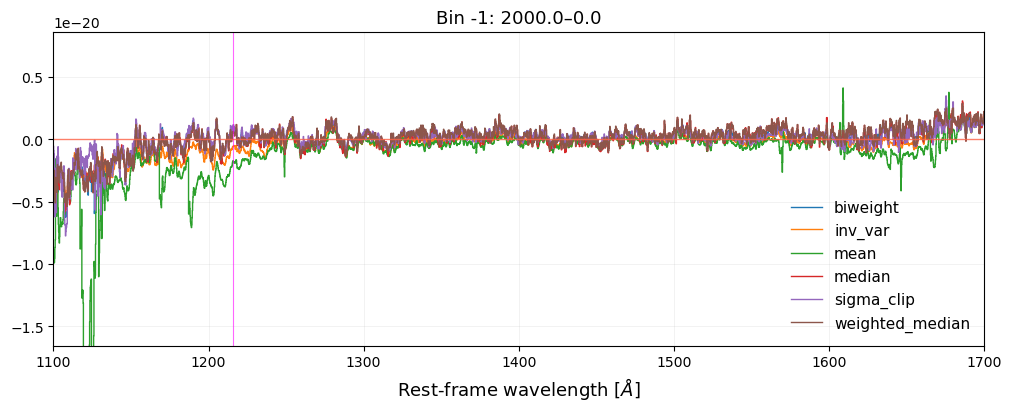

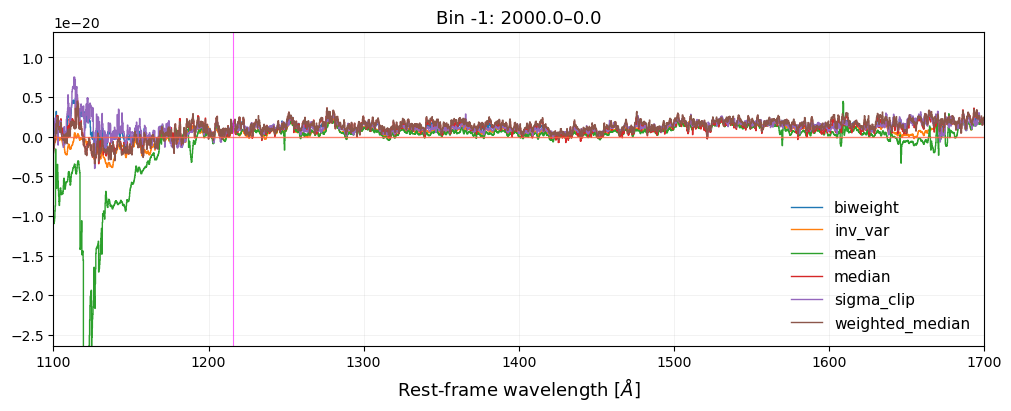

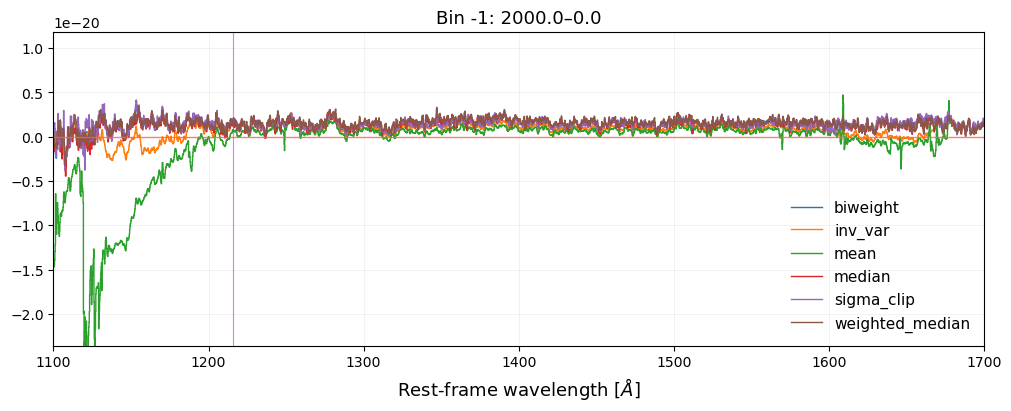

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Bin -1: 2000.0–0.0'}, xlabel='Rest-frame wavelength [$\\AA$]'>)

In [10]:
# plotting.plot_methods_overlay(stacks['old_200A'],
#     methods=None,
#     radial_index=-1,
#     xlim=spexlim,
#     smooth=None,
#     title=None,
#     set_ylim=True,
#     ylim_pad=0.25,
#     ylim_percentiles=(1, 99),
#     include_zero=False)

plotting.plot_methods_overlay(stacks['new_25G'],
    methods=None,
    radial_index=-1,
    xlim=spexlim,
    smooth=None,
    title=None,
    set_ylim=True,
    ylim_pad=0.25,
    ylim_percentiles=(1, 99),
    include_zero=False)

plotting.plot_methods_overlay(stacks['100G'],
    methods=None,
    radial_index=-1,
    xlim=spexlim,
    smooth=None,
    title=None,
    set_ylim=True,
    ylim_pad=0.25,
    ylim_percentiles=(1, 99),
    include_zero=False)

plotting.plot_methods_overlay(stacks['200A'],
    methods=None,
    radial_index=-1,
    xlim=spexlim,
    smooth=None,
    title=None,
    set_ylim=True,
    ylim_pad=0.25,
    ylim_percentiles=(1, 99),
    include_zero=False)

plotting.plot_methods_overlay(stacks['im_200A'],
    methods=None,
    radial_index=-1,
    xlim=spexlim,
    smooth=None,
    title=None,
    set_ylim=True,
    ylim_pad=0.25,
    ylim_percentiles=(1, 99),
    include_zero=False)

plotting.plot_methods_overlay(stacks['100G_100105'],
    methods=None,
    radial_index=-1,
    xlim=spexlim,
    smooth=None,
    title=None,
    set_ylim=True,
    ylim_pad=0.25,
    ylim_percentiles=(1, 99),
    include_zero=False)

plotting.plot_methods_overlay(stacks['100G_2030'],
    methods=None,
    radial_index=-1,
    xlim=spexlim,
    smooth=None,
    title=None,
    set_ylim=True,
    ylim_pad=0.25,
    ylim_percentiles=(1, 99),
    include_zero=False)

plotting.plot_methods_overlay(stacks['100G_galbg'],
    methods=None,
    radial_index=-1,
    xlim=spexlim,
    smooth=None,
    title=None,
    set_ylim=True,
    ylim_pad=0.25,
    ylim_percentiles=(1, 99),
    include_zero=False)

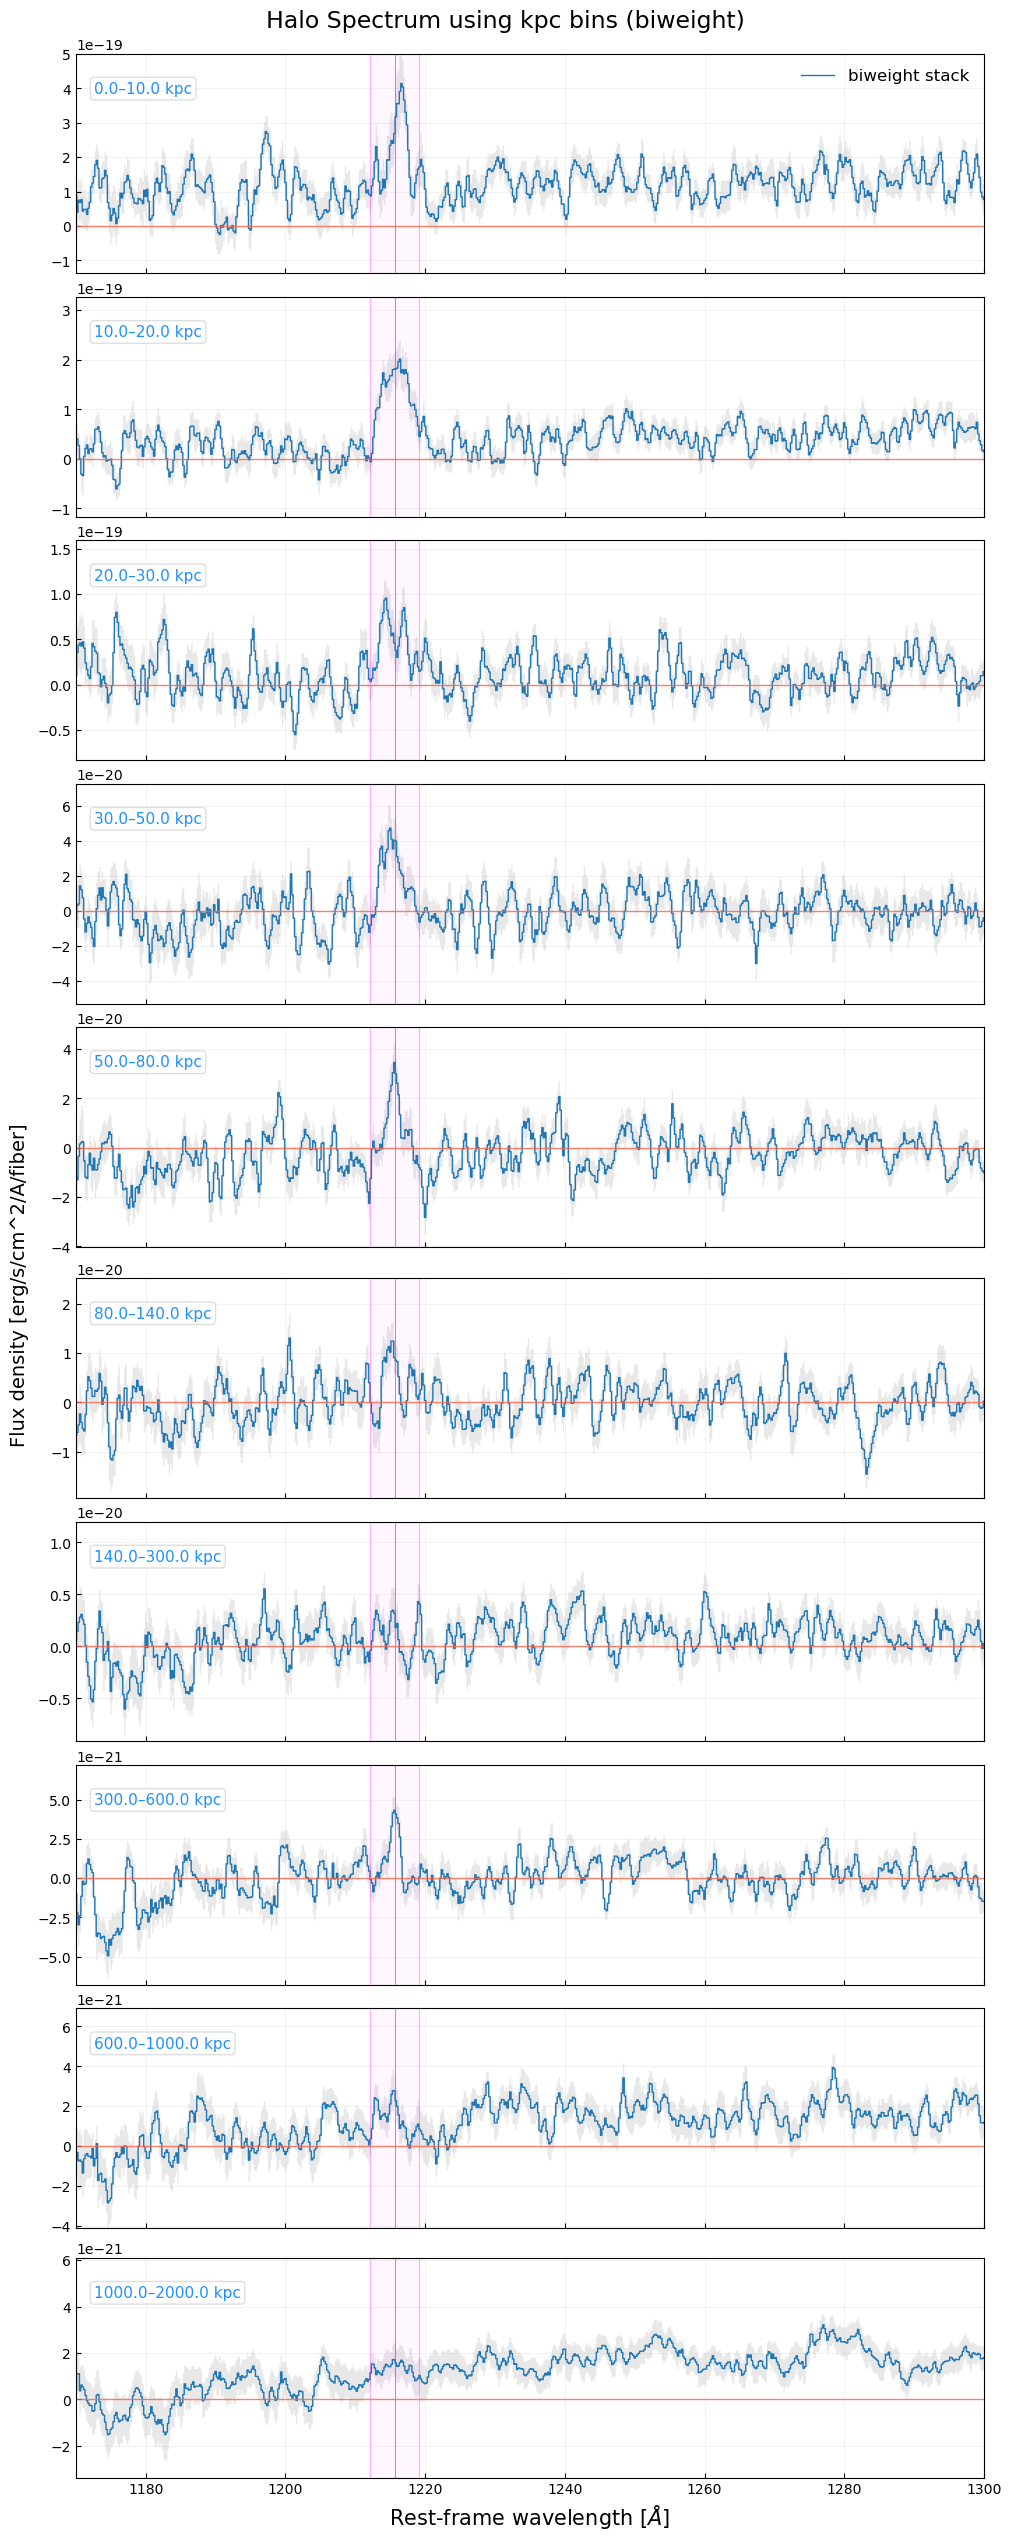

(<Figure size 1000x2500 with 10 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >,
        <Axes: xlabel='Rest-frame wavelength [$\\AA$]'>], dtype=object))

In [11]:
plotting.plot_stack_panels(stacks['100G_SG'],
    method="biweight",
    distance_type=bin_mode,
    title=None,
    xlim=(1170, 1300),
    lya_window=half_width,
    figsize_width=10,
    panel_height=2.5,
    show_err=True,
    smooth=None,
    savepath=None,
    dpi=300)

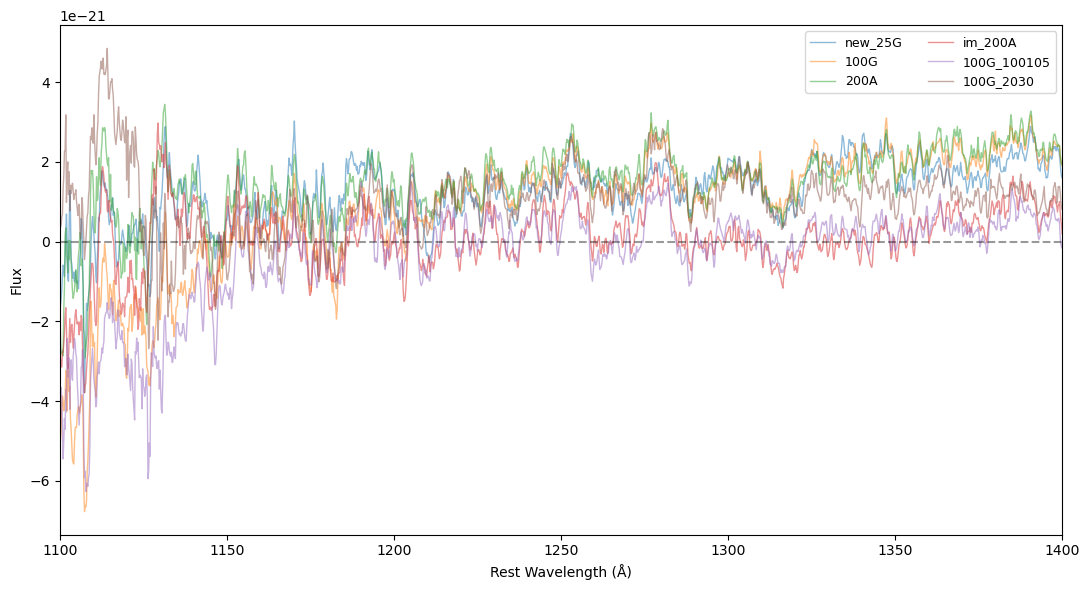

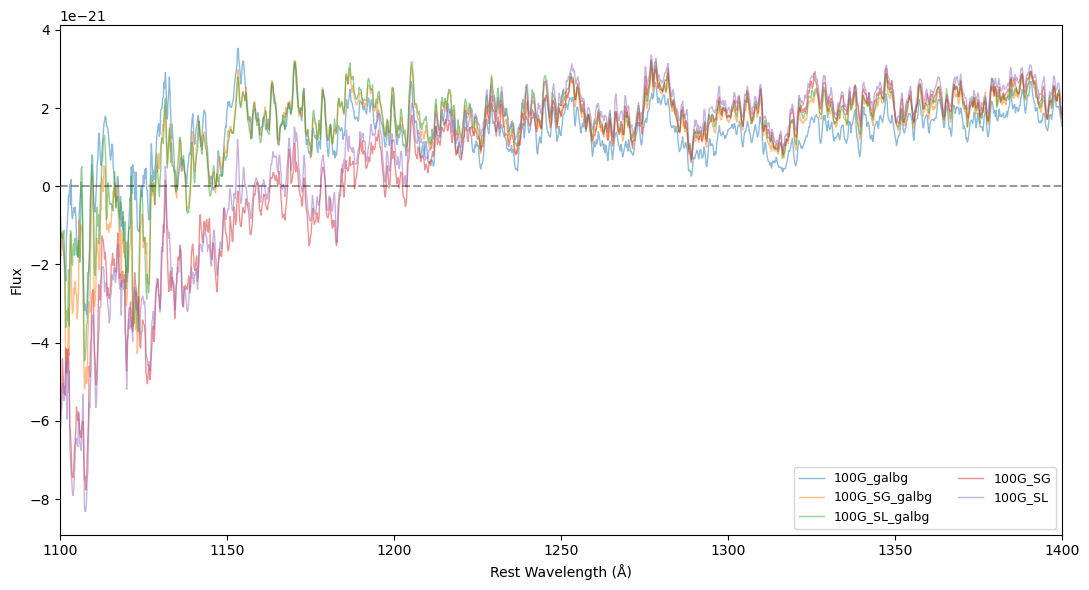

In [12]:
# ------------------------------------------------------------------
# Choose which radial bin / sub-stack to plot
# ------------------------------------------------------------------
index = -1

# Which stacking method to compare
method = "biweight"

# Products to plot (in desired order)
labels1 = [
    #"old_200A",
    "new_25G",
    "100G",
    "200A",
    "im_200A",
    "100G_100105",
    "100G_2030",
]

labels2 = [
    "100G_galbg",
    "100G_SG_galbg",
    "100G_SL_galbg",
    "100G_SG",
    "100G_SL",
]

#Define wavelength axis
wave = stacks['new_25G']['rest_wave']

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

for label in labels1:
    s = stacks[label]["stacks"][method]
    flux = s["flux"][index]
    ax.plot(wave, flux,
        lw=1, alpha=0.5,
        label=label)
    
# Cosmetics
ax.set_xlim(1100, 1400)
ax.set_xlabel("Rest Wavelength (Å)")
ax.set_ylabel("Flux")
ax.axhline(0, color="k", ls="--", alpha=0.4)
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

# -----------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

for label in labels2:
    s = stacks[label]["stacks"][method]
    flux = s["flux"][index]
    ax.plot(wave, flux,
        lw=1, alpha=0.5,
        label=label)
    
# Cosmetics
ax.set_xlim(1100, 1400)
ax.set_xlabel("Rest Wavelength (Å)")
ax.set_ylabel("Flux")
ax.axhline(0, color="k", ls="--", alpha=0.4)
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

# Comparing Additive Offset and Noisiness in Outer Bins

In [15]:
def rank_products(scores, labels=None, bins=None, core_skip=3,
                  methods=("mean_rank", "mean_rel", "nonwin"),
                  normalize=True):
    """
    Rank products by continuum noise, three ways + a multiplicative composite.

    scores : {label: {"noise_per_bin": (nbin_all,), "n_fib_per_bin": (nbin_all,)}}
             (the dict from opt.noise_from_stacks per product)
    labels : which products, in order (default: all keys of `scores`)
    bins   : explicit bin indices to score on. If None, uses core_skip: onward.
    core_skip : drop the first N (unreliable core) bins when bins is None. Default 3.
    methods : which metrics enter the COMPOSITE product. All three are always
              computed and returned; this only controls the multiplication.
                'mean_rank' -- mean per-bin rank (1=best). higher = worse.
                'mean_rel'  -- mean (noise / best-in-bin). higher = worse.
                'nonwin'    -- losses+1 = (nbin - wins) + 1. higher = worse.
                               (win count flipped so higher counts AGAINST it,
                                +1 so a perfect winner contributes 1 not 0.)
    normalize : divide each metric by its own best-product value before
                multiplying, so every metric starts at 1.0 for its winner and
                contributes an equal PROPORTIONAL penalty (the "counts equally"
                property). False -> raw product (wide-range metrics dominate).

    Returns dict: labels, bins, metrics{mean_rank, mean_rel, nonwin, wins,
    composite}, order (best->worst indices), composite_rank (1=best).
    """
    labels = list(scores) if labels is None else list(labels)
    N = np.vstack([np.asarray(scores[L]["noise_per_bin"], float) for L in labels])
    nprod, nbin_all = N.shape
    if bins is None:
        bins = np.arange(core_skip, nbin_all)
    bins = np.asarray(bins)
    Nb = N[:, bins]
    if not np.all(np.isfinite(Nb)):
        raise ValueError("selected bins contain NaN/inf; restrict `bins` to finite ones")
    nbin = Nb.shape[1]

    perbin_rank = np.argsort(np.argsort(Nb, axis=0), axis=0) + 1   # 1=best per bin
    rel  = Nb / np.min(Nb, axis=0, keepdims=True)                  # 1=best per bin
    wins = (Nb == np.min(Nb, axis=0, keepdims=True)).sum(axis=1)   # higher=better

    metrics = {"mean_rank": perbin_rank.mean(axis=1),
               "mean_rel":  rel.mean(axis=1),
               "nonwin":    1.0 + (nbin - wins)}
    comp = np.ones(nprod)
    for m in methods:
        v = metrics[m].astype(float)
        if normalize:
            v = v / np.min(v)
        comp *= v
    metrics["composite"] = comp
    metrics["wins"] = wins.astype(float)                          # display only

    return dict(labels=labels, bins=bins, metrics=metrics,
                order=np.argsort(metrics["composite"]),
                composite_rank=np.argsort(np.argsort(metrics["composite"])) + 1)


def print_ranking(R):
    labels, M, order = R["labels"], R["metrics"], R["order"]
    print(f"{'rank':>4} {'product':<14} {'composite':>10} {'mean_rank':>10} "
          f"{'mean_rel':>9} {'wins':>5} {'nonwin':>7}")
    for r, i in enumerate(order, 1):
        print(f"{r:>4} {labels[i]:<14} {M['composite'][i]:>10.3f} {M['mean_rank'][i]:>10.2f} "
              f"{M['mean_rel'][i]:>9.3f} {int(M['wins'][i]):>5} {M['nonwin'][i]:>7.0f}")


def plot_ranking(R, figsize=(12, 8)):
    labels, M = R["labels"], R["metrics"]
    panels = [("mean_rank", "mean per-bin rank"),
              ("mean_rel",  "mean noise / bin-best"),
              ("nonwin",    "non-win score (losses+1)"),
              ("composite", "COMPOSITE (product)")]
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    for ax, (key, title) in zip(axes.ravel(), panels):
        o = np.argsort(M[key])
        vals = M[key][o]; names = [labels[i] for i in o]
        ax.barh(names, vals, color=cm.RdYlGn_r(vals / vals.max()))
        ax.invert_yaxis(); ax.set_title(title); ax.set_xlabel("(lower = better)")
        for j, v in enumerate(vals):
            ax.text(v, j, f" {v:.2f}", va="center", fontsize=8)
    fig.suptitle("Ranking each product: 3 metrics + multiplicative composite", fontsize=13)
    plt.tight_layout(); plt.show()
    return fig

In [14]:
def plot_all_info(scores, labels=None, figsize=(15, 4.5)):
    """
    Overview of every PER-BIN quantity the metric extracts, one panel each:
    noise (log), height (signed, w/ zero line), fiber count. height and nfib
    are shown for context -- neither is ranked.

    scores : {label: result dict from opt.noise_from_stacks} -- needs
             noise_per_bin, height_per_bin, n_fib_per_bin.
    """
    labels = list(scores) if labels is None else list(labels)
    colors = cm.tab10(np.linspace(0, 1, len(labels)))
    nrad = len(scores[labels[0]]["noise_per_bin"])

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    for L, c in zip(labels, colors):
        axes[0].plot(range(nrad), scores[L]["noise_per_bin"],  marker="o", color=c, label=L)
        axes[1].plot(range(nrad), scores[L]["height_per_bin"], marker="s", color=c, label=L)
        axes[2].plot(range(nrad), scores[L]["n_fib_per_bin"],  marker="^", color=c, label=L)
    axes[0].set_yscale("log"); axes[0].set_title("NOISE (RMS bootstrap-σ)"); axes[0].set_ylabel("flux")
    axes[1].axhline(0, color="k", lw=0.8, ls="--")
    axes[1].set_title("HEIGHT (level / pedestal)"); axes[1].set_ylabel("flux (signed)")
    axes[2].set_title("FIBER COUNT (context)"); axes[2].set_ylabel("Σ nfib")
    for ax in axes: ax.set_xlabel("radial bin index")
    axes[0].legend(fontsize=6, ncol=2)
    fig.suptitle("All per-bin quantities the metric extracts", fontsize=13)
    plt.tight_layout(); plt.show()
    return fig


def plot_spectra(scores, label, figsize=(10, 7)):
    """
    For ONE product: the fiducial continuum_spectrum (see pedestal/wiggle shape)
    and the per-pixel err_spectrum, both over the line-free window, one line per
    radial bin.
    """
    S = scores[label]; wv = S["window_wave"]; nrad = S["continuum_spectrum"].shape[0]
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    for r in range(nrad):
        axes[0].plot(wv, S["continuum_spectrum"][r], lw=0.8, alpha=0.7, label=f"bin {r}")
        axes[1].plot(wv, S["err_spectrum"][r],        lw=0.8, alpha=0.7)
    axes[0].axhline(0, color="k", lw=0.8, ls="--")
    axes[0].set_title(f"'{label}' continuum (fiducial stack, line-free px)")
    axes[0].set_ylabel("flux"); axes[0].legend(fontsize=6, ncol=4)
    axes[1].set_title("err_spectrum (per-pixel bootstrap-σ)")
    axes[1].set_ylabel("σ"); axes[1].set_xlabel("rest wavelength (Å)")
    plt.tight_layout(); plt.show()
    return fig

In [16]:
scores = {
    L: optimize.noise_from_stacks(
        stacks[L], cfg_for[L],
        window=(1150.0, 1300.0),
        lines=DEFAULT_UV_LINES, line_hw=5.0,
        stack_method=None, height_reduce="biweight",
        nboot=500, reduce="rms", seed=random_seed,
    )
    for L in stacks
}

In [ ]:
fig, tbl = optimize.plot_score_summary(scores)     # the two histograms
tbl.pprint_all()                              # same ranking, as text

In [ ]:
opt.plot_bin_detail(scores, 0)                # innermost bin
opt.plot_bin_detail(scores, 5)                # middle-ish bin
opt.plot_bin_detail(scores, -1)               # outermost bin

In [ ]:
# tweaks: drop innermost bin, green harder, log the noise axis
opt.plot_score_summary(scores, bin_slice=slice(1, None),
                       rank_gamma=2.5, log_y_noise=True, sort_by="mean_rank")

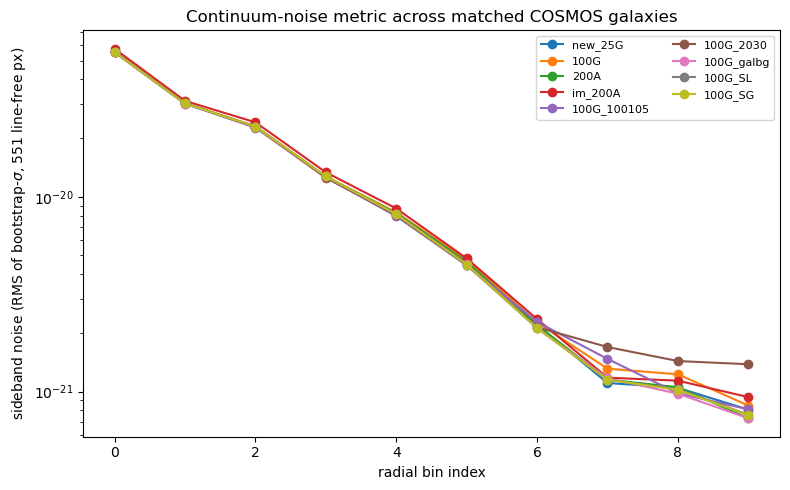

In [16]:
# ============================================================================
# PLOT: sideband noise vs radial bin, one curve per product
# ============================================================================
fig, ax = plt.subplots(figsize=(8, 5))
for L, r in scores.items():
    nbin = len(r["noise_per_bin"])
    ax.plot(range(nbin), r["noise_per_bin"], marker="o", label=L)
ax.set_xlabel("radial bin index")
ax.set_ylabel(f"sideband noise (RMS of bootstrap-$\\sigma$, {scores[next(iter(scores))]['n_window_px']} line-free px)")
ax.set_yscale("log")
ax.legend(fontsize=8, ncol=2)
ax.set_title("Continuum-noise metric across matched COSMOS galaxies")
plt.tight_layout()
plt.show()

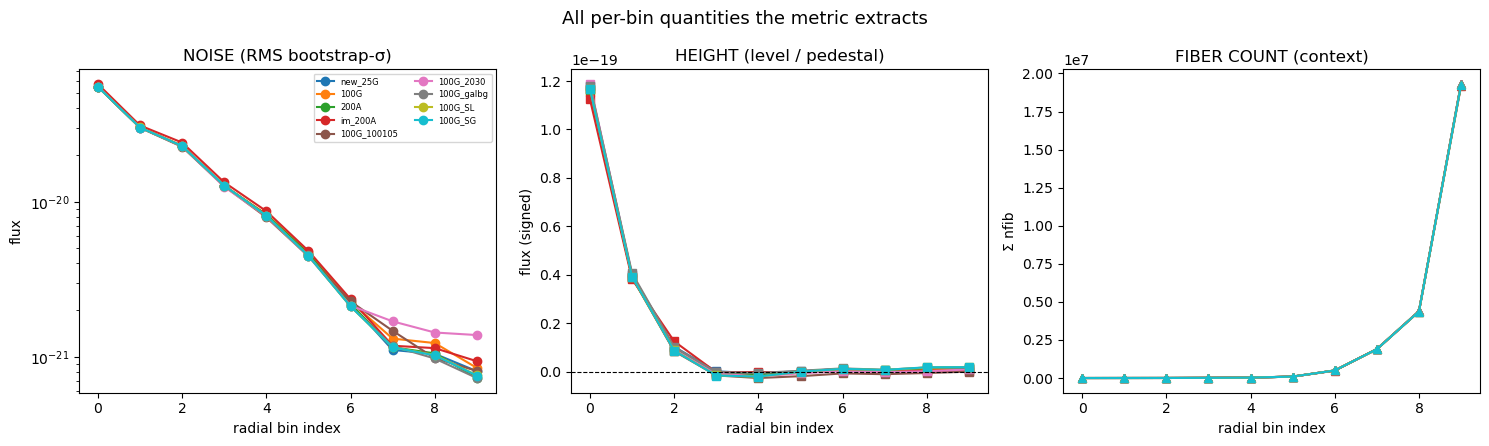

In [18]:
_ = plot_all_info(scores)          # noise / height / nfib across bins, all products

rank product         composite  mean_rank  mean_rel  wins  nonwin
   1 100G_galbg          1.167       3.43     1.017     1       7
   2 100G_SL             1.276       3.71     1.027     1       7
   3 100G_100105         1.492       4.14     1.076     1       7
   4 100G_SG             1.568       4.00     1.025     0       8
   5 new_25G             1.594       4.57     1.042     1       7
   6 200A                1.685       4.86     1.036     1       7
   7 100G_2030           1.828       5.00     1.274     2       6
   8 100G                3.046       7.14     1.115     0       8
   9 im_200A             3.505       8.14     1.125     0       8


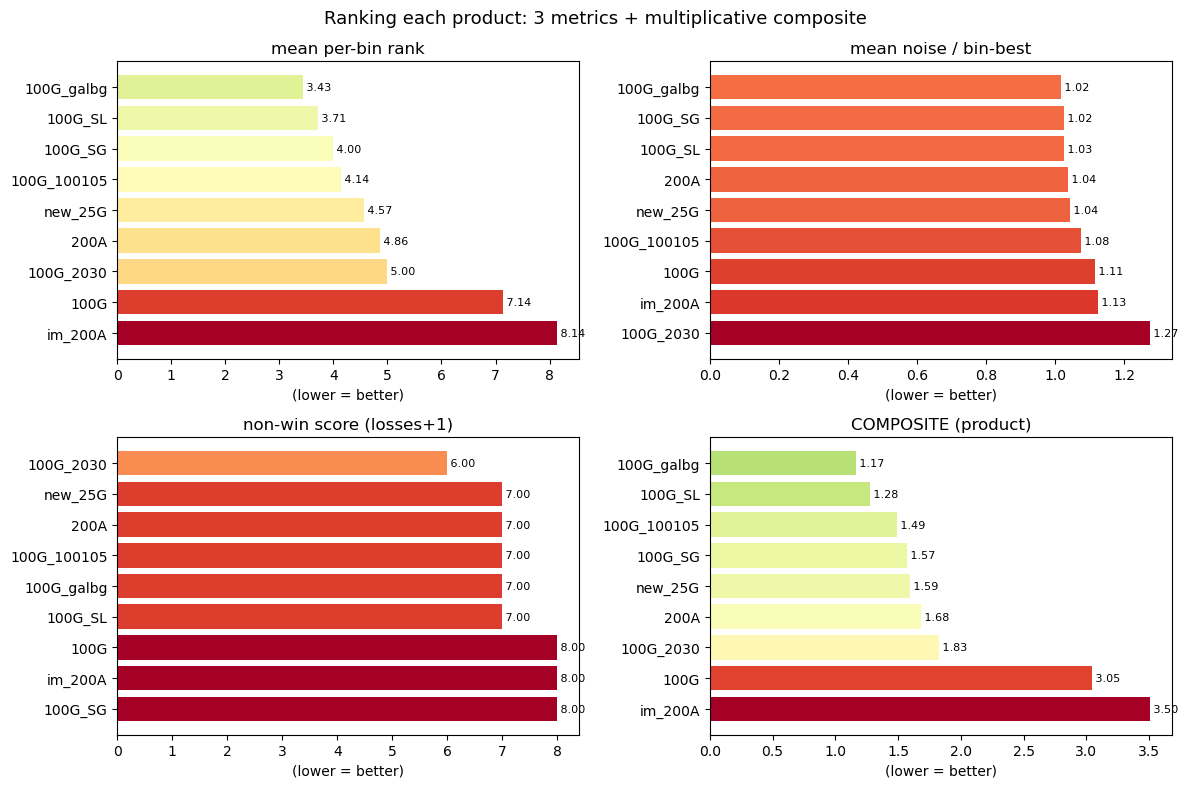

In [19]:
R = rank_products(scores, core_skip=3)          # or bins=[3,4,5,6,7] explicitly
print_ranking(R)                                # printed leaderboard
plot_ranking(R)                                 # 2x2 bar panel

# pick which metrics go into the composite (still see all three individually):
R_two = rank_products(scores, methods=("mean_rank", "mean_rel"))   # drop win count
R_raw = rank_products(scores, normalize=False)                     # raw product

In [21]:
R_raw

{'labels': ['new_25G',
  '100G',
  '200A',
  'im_200A',
  '100G_100105',
  '100G_2030',
  '100G_galbg',
  '100G_SL',
  '100G_SG'],
 'bins': array([3, 4, 5, 6, 7, 8, 9]),
 'metrics': {'mean_rank': array([4.57142857, 7.14285714, 4.85714286, 8.14285714, 4.14285714,
         5.        , 3.42857143, 3.71428571, 4.        ]),
  'mean_rel': array([1.04198041, 1.11483897, 1.03629169, 1.12522179, 1.07593147,
         1.27437923, 1.01663669, 1.02654152, 1.02497596]),
  'nonwin': array([7., 8., 7., 8., 7., 6., 7., 7., 8.]),
  'composite': array([33.34337315, 63.7050838 , 35.23391739, 73.30016256, 31.20201253,
         38.23137695, 24.3992806 , 26.69007949, 32.79923064]),
  'wins': array([1., 0., 1., 0., 1., 2., 1., 1., 0.])},
 'order': array([6, 7, 4, 8, 0, 2, 5, 1, 3]),
 'composite_rank': array([5, 8, 6, 9, 3, 7, 1, 2, 4])}

# Segmentation vs Percentile Image Mask

In [220]:
def per_fiber_continuum(spectra, step=5):
    """Per-fiber median continuum, streaming over exposures so only one
    (nfib, nwave) exposure is in RAM at a time. spectra: (nexp, nfib, nwave); memmap ok."""
    nexp, nfib = spectra.shape[:2]
    out = np.full((nexp, nfib), np.nan, np.float32)
    for i in range(nexp):
        out[i] = np.nanmedian(spectra[i][:, ::step], axis=1)
    return out

def _nn_arcsec(ra, dec, ra_ref, dec_ref):
    """Nearest-neighbor separation (arcsec) from each (ra,dec) to a reference set,
    tangent-plane approx (fine within one field)."""
    ra, dec = np.asarray(ra, float), np.asarray(dec, float)
    ra_ref, dec_ref = np.asarray(ra_ref, float), np.asarray(dec_ref, float)
    ok = np.isfinite(ra_ref) & np.isfinite(dec_ref)
    if ok.sum() == 0 or len(ra) == 0:
        return np.full(len(ra), np.nan)
    cosd = np.cos(np.radians(np.nanmean(dec)))
    tree = cKDTree(np.column_stack([ra_ref[ok] * cosd, dec_ref[ok]]))
    d, _ = tree.query(np.column_stack([ra * cosd, dec]), k=1)
    return d * 3600.0

def compare_masks(RA_fibers, DEC_fibers, *, seg_mask_path,
                  cont_image_filepath, field, percentile=90,
                  fiber_cont=None, spectra=None, step=5,
                  gal_RA=None, gal_DEC=None, near_as=2.0):
    """
    Fiber-level A/B of SEGMAP vs IMAGE-PERCENTILE on the SAME fibers. Buckets the
    disagreement fibers so each hypothesis has a discriminator:
      brightness (cont_med)        : faint  -> segmap finds sub-threshold sources
                                     bright -> bright cores / star wings
      d_gal_med (to catalog gal)   : small on img_only -> percentile self-masks the
                                     science galaxies segmap protects (documented)
      d_bright_med (to bright src) : small on img_only -> bright-star wings segmap misses
      frac_near_bad                : high   -> dilation/boundary difference, NOT a
                                     new detection
    """
    seg = np.asarray(masking.segmentation_mask(
        seg_mask_path, RA_fibers, DEC_fibers, confirmation=False)).ravel()
    img = np.asarray(masking.continuum_image_mask(
        cont_image_filepath, field, percentile, RA_fibers, DEC_fibers,
        confirmation=False)).ravel()

    ra  = np.asarray(RA_fibers,  float).ravel()
    dec = np.asarray(DEC_fibers, float).ravel()
    fin = np.isfinite(ra) & np.isfinite(dec)

    if fiber_cont is None:
        if spectra is None:
            raise ValueError("pass fiber_cont, or spectra to compute it")
        fiber_cont = per_fiber_continuum(spectra, step=step)
    cont = np.asarray(fiber_cont, float).ravel()

    both, seg_only = seg & img, seg & ~img
    img_only, neither = ~seg & img, ~seg & ~img
    bright = fin & (cont > np.nanpercentile(cont[fin], 99))   # bright-source tracer

    def stats(m):
        m = m & fin
        n = int(m.sum())
        if n == 0:
            return {"n": 0}
        d_gal = (_nn_arcsec(ra[m], dec[m], gal_RA, gal_DEC)
                 if gal_RA is not None else None)
        d_bad = _nn_arcsec(ra[m], dec[m], ra[both & fin], dec[both & fin])
        return {"n": n,
                "cont_med":     float(np.nanmedian(cont[m])),
                "d_gal_med":    None if d_gal is None else float(np.nanmedian(d_gal)),
                "d_bright_med": float(np.nanmedian(_nn_arcsec(ra[m], dec[m],
                                                             ra[bright], dec[bright]))),
                "frac_near_bad": float(np.mean(d_bad <= near_as))}

    return {"seg": seg, "img": img, "fin": fin, "cont": cont,
            "counts": {k: int((v & fin).sum()) for k, v in
                       [("both", both), ("seg_only", seg_only),
                        ("img_only", img_only), ("neither", neither)]}
                     | {"n_fibers": int(fin.sum())},
            "seg_only": stats(seg_only), "img_only": stats(img_only),
            "both": stats(both),
            "good_cont_med": float(np.nanmedian(cont[neither & fin]))}


def compare_masks_fast(RA, DEC, seg, img, fiber_cont, gal_RA=None, gal_DEC=None, near_as=2.0):
    ra, dec = np.asarray(RA,float).ravel(), np.asarray(DEC,float).ravel()
    seg, img = np.asarray(seg).ravel(), np.asarray(img).ravel()
    cont = np.asarray(fiber_cont,float).ravel()
    fin = np.isfinite(ra) & np.isfinite(dec)
    both, seg_only, img_only, neither = seg&img, seg&~img, ~seg&img, ~seg&~img
    bright = fin & (cont > np.nanpercentile(cont[fin], 99))
    def stats(m):
        m = m & fin; n = int(m.sum())
        if n == 0: return {"n": 0}
        d_gal = _nn_arcsec(ra[m],dec[m],gal_RA,gal_DEC) if gal_RA is not None else None
        return {"n": n, "cont_med": float(np.nanmedian(cont[m])),
                "d_gal_med": None if d_gal is None else float(np.nanmedian(d_gal)),
                "d_bright_med": float(np.nanmedian(_nn_arcsec(ra[m],dec[m],ra[bright],dec[bright]))),
                "frac_near_bad": float(np.mean(_nn_arcsec(ra[m],dec[m],ra[both&fin],dec[both&fin])<=near_as))}
    return {"seg":seg,"img":img,"fin":fin,"cont":cont,
            "counts":{"both":int((both&fin).sum()),"seg_only":int((seg_only&fin).sum()),
                      "img_only":int((img_only&fin).sum()),"neither":int((neither&fin).sum()),
                      "n_fibers":int(fin.sum())},
            "seg_only":stats(seg_only),"img_only":stats(img_only),"both":stats(both),
            "good_cont_med":float(np.nanmedian(cont[neither&fin]))}


def get_mask_cached(kind, RA, DEC, cache, **kw):
    """Compute a fiber mask once, then load from disk. kind: 'seg' or 'img'."""
    if os.path.exists(cache):
        return np.load(cache)
    if kind == "seg":
        m = masking.segmentation_mask(kw["seg_mask_path"], RA, DEC, confirmation=False)
    elif kind == "img":
        m = masking.continuum_image_mask(kw["cont_image_filepath"], kw["field"],
                                         kw["percentile"], RA, DEC, confirmation=False)
    else:
        raise ValueError(kind)
    m = np.asarray(m)
    np.save(cache, m)
    print(f"cached {kind} mask -> {cache}  ({m.sum():,} bad / {m.size:,})")
    return m


def per_fiber_continuum_pbar(spectra, step=5, cache="cache_cont_COSMOS.npy"):
    if os.path.exists(cache):
        return np.load(cache)
    nexp, nfib = spectra.shape[:2]
    out = np.full((nexp, nfib), np.nan, np.float32)
    for i in tqdm(range(nexp), desc="per-fiber continuum"):   # one exposure at a time
        out[i] = np.nanmedian(spectra[i][:, ::step], axis=1)
    np.save(cache, out)
    return out


def compare_masks_in_annulus(R, gal_RA, gal_DEC, ra, dec, inner_as=55.0, outer_as=65.0):
    """
    Restrict the seg/img bucket comparison to fibers actually eligible for the
    BACKGROUND ANNULUS (fixed arcsec range -> a simple, unambiguous cut, unlike
    the kpc-based science bins which need per-galaxy redshift). This is the
    subset that determines the background level/scatter you're diagnosing --
    the field-wide comparison mixes in ~3.7M fibers nowhere near an annulus.
    """
    ra, dec = np.asarray(ra, float).ravel(), np.asarray(dec, float).ravel()
    fin = R["fin"]
    d_gal = _nn_arcsec(ra[fin], dec[fin], gal_RA, gal_DEC)   # per-fiber, finite only
    in_ann = np.zeros(fin.size, bool)
    in_ann[fin] = (d_gal >= inner_as) & (d_gal <= outer_as)

    seg, img = R["seg"], R["img"]
    both, seg_only, img_only, neither = seg&img, seg&~img, ~seg&img, ~seg&~img
    counts = {k: int((m & in_ann).sum()) for k, m in
              [("both", both), ("seg_only", seg_only),
               ("img_only", img_only), ("neither", neither)]}
    counts["n_annulus"] = int(in_ann.sum())
    for k, m in [("both", both), ("seg_only", seg_only), ("img_only", img_only)]:
        n = counts[k]
        counts[f"{k}_cont_med"] = float(np.nanmedian(R["cont"][m & in_ann])) if n else np.nan
    return counts


def compare_masks_in_aperture(R, gal_RA, gal_DEC, ra, dec, z, r_kpc_edges,
                              cosmo, bin_index=0):
    """
    Same seg/img bucket comparison as compare_masks_in_annulus, but for a SCIENCE
    APERTURE radial bin (kpc -> arcsec is per-galaxy via angular diameter distance,
    unlike the fixed-arcsec annulus). Checks whether the aperture is masked
    consistently with the annulus -- if the same seg_only/img_only asymmetry
    appears there, segmap's lower background is the physically consistent choice;
    if it doesn't, the DC offset may be a genuine annulus-vs-aperture mismatch.
    """
    ra, dec, z = np.asarray(ra,float).ravel(), np.asarray(dec,float).ravel(), np.asarray(z,float)
    fin = R["fin"]
    d_gal_as = np.full(fin.sum(), np.nan)
    # nearest galaxy AND that galaxy's redshift, for a proper per-fiber kpc->arcsec
    from scipy.spatial import cKDTree
    cosd = np.cos(np.radians(np.nanmean(dec[fin])))
    tree = cKDTree(np.column_stack([gal_RA*cosd, gal_DEC]))
    d_deg, j = tree.query(np.column_stack([ra[fin]*cosd, dec[fin]]), k=1)
    d_as = d_deg * 3600.0
    z_near = z[j]
    kpc_per_as = cosmo.kpc_proper_per_arcmin(z_near).value / 60.0
    d_kpc = d_as * kpc_per_as

    lo, hi = r_kpc_edges[bin_index], r_kpc_edges[bin_index + 1]
    in_ap = np.zeros(fin.size, bool)
    in_ap[fin] = (d_kpc >= lo) & (d_kpc < hi)

    seg, img = R["seg"], R["img"]
    both, seg_only, img_only = seg&img, seg&~img, ~seg&img
    out = {"n_aperture": int(in_ap.sum())}
    for k, m in [("both", both), ("seg_only", seg_only), ("img_only", img_only)]:
        n = int((m & in_ap).sum())
        out[k] = n
        out[f"{k}_cont_med"] = float(np.nanmedian(R["cont"][m & in_ap])) if n else np.nan
    return out


def classify_aperture_img_only(R, gal_RA, gal_DEC, ra, dec, z, r_kpc_edges,
                               cosmo, bin_index, target_id, target_idx,
                               near_target_as=3.0):
    """
    For the img_only bucket in ONE aperture bin: is the extra flux percentile
    masks (that segmap keeps) sitting on the TARGET galaxy's own extended wing,
    or on some OTHER nearby source (a genuine interloper)? Splits img_only by
    distance to the target itself vs. distance to the nearest catalog galaxy of
    ANY kind. Small target-distance + not-nearest-to-something-else = halo wing
    (segmap correctly preserving science signal). Small distance to a DIFFERENT
    galaxy = interloper (segmap incorrectly including contamination).
    """
    ra, dec, z = np.asarray(ra,float).ravel(), np.asarray(dec,float).ravel(), np.asarray(z,float)
    fin = R["fin"]
    from scipy.spatial import cKDTree
    cosd = np.cos(np.radians(np.nanmean(dec[fin])))

    # distance to the TARGET galaxy specifically
    tra, tdec = gal_RA[target_idx], gal_DEC[target_idx]
    d_target_as = _nn_arcsec(ra[fin], dec[fin], np.array([tra]), np.array([tdec]))

    # distance to nearest catalog galaxy OF ANY KIND (for the interloper check)
    tree = cKDTree(np.column_stack([gal_RA*cosd, gal_DEC]))
    d_deg, j = tree.query(np.column_stack([ra[fin]*cosd, dec[fin]]), k=1)
    d_any_as = d_deg * 3600.0
    is_nearest_to_target = (j == target_idx)

    kpc_per_as = cosmo.kpc_proper_per_arcmin(z[target_idx]).value / 60.0
    d_kpc = d_target_as * kpc_per_as
    lo, hi = r_kpc_edges[bin_index], r_kpc_edges[bin_index + 1]
    in_ap = np.zeros(fin.size, bool)
    in_ap[fin] = (d_kpc >= lo) & (d_kpc < hi)

    img_only = (~R["seg"] & R["img"]) & in_ap
    m = img_only[fin[in_ap]] if False else img_only[in_ap]   # align to in_ap subset below
    idx = np.flatnonzero(img_only)
    n = idx.size
    if n == 0:
        return {"n": 0}
    nearest_flag = np.zeros(fin.size, bool); nearest_flag[fin] = is_nearest_to_target
    wing = nearest_flag[idx]                 # nearest catalog galaxy IS the target
    return {"n": n, "n_wing_like": int(wing.sum()), "n_interloper_like": int((~wing).sum()),
            "frac_wing_like": float(wing.mean())}


def mask_offset_asymmetry(R, ann, ap):
    """
    The offset only survives if masking shifts the background level DIFFERENTLY
    in the annulus (where bg is estimated) than in the aperture (where it's
    applied). Compares the seg-vs-percentile flux difference across the two zones
    using the bucket cont_meds already computed. A nonzero gap = net (over)subtraction;
    ~0 gap = the level shift cancels and the offset is coming from elsewhere.
    ann, ap: the dicts from compare_masks_in_annulus / compare_masks_in_aperture.
    """
    # flux segmap KEEPS but percentile masks (img_only) minus flux segmap masks
    # but percentile keeps (seg_only): net flux difference seg - percentile, per zone
    def net(z):
        return (z["img_only"] * z["img_only_cont_med"]      # kept by seg, dropped by pct
                - z["seg_only"] * z["seg_only_cont_med"]) / z.get("n_annulus", z.get("n_aperture"))
    ann_net, ap_net = net(ann), net(ap)
    return {"annulus_net_flux_diff": ann_net,
            "aperture_net_flux_diff": ap_net,
            "asymmetry": ap_net - ann_net}   # this is your predicted net over/under-subtraction sign

In [27]:
vdfi = extract.load_field(cfg_test)

# --- example: compute masks ONCE (slow only the first time), then compare instantly ---
seg = get_mask_cached("seg", vdfi['RA'], vdfi['DEC'], "cache_seg_COSMOS.npy",
                      seg_mask_path="catalogs/images/fibermask_COSMOS.fits")
img = get_mask_cached("img", vdfi['RA'], vdfi['DEC'], "cache_img_COSMOS.npy",
                      cont_image_filepath="../../../../HETDEX-Work/vdfi/cosmos/CFHT_COSMOS_image.fits",
                      field="COSMOS", percentile=90)

Loaded COSMOS: 132 exposures, 34944 fibers, 1036 wavelength pixels


In [15]:
# --- example: the actual comparison, now instant after the one-time caching ---
cont = per_fiber_continuum_pbar(vdfi['spectra'])
R = compare_masks_fast(vdfi['RA'], vdfi['DEC'], seg, img, cont,
                       gal_RA=catalog["RA"], gal_DEC=catalog["DEC"])

per-fiber continuum:   0%|          | 0/132 [00:00<?, ?it/s]/tmp/ipykernel_12801/3022076553.py:129: RuntimeWarning: All-NaN slice encountered
  out[i] = np.nanmedian(spectra[i][:, ::step], axis=1)
per-fiber continuum: 100%|██████████| 132/132 [02:01<00:00,  1.09it/s]


In [28]:
print(R["counts"])
for k in ("seg_only","img_only","both"):
    print(k, R[k])

{'both': 258710, 'seg_only': 294244, 'img_only': 352159, 'neither': 3707495, 'n_fibers': 4612608}
seg_only {'n': 294244, 'cont_med': 0.007215043995529413, 'd_gal_med': 138.0390893837303, 'd_bright_med': 18.710901981512443, 'frac_near_bad': 0.06431057217819225}
img_only {'n': 352159, 'cont_med': -0.0004519254725892097, 'd_gal_med': 136.01100962070117, 'd_bright_med': 5.076908294359502, 'frac_near_bad': 0.5520318946839354}
both {'n': 258710, 'cont_med': 0.036421481519937515, 'd_gal_med': 131.76943930725827, 'd_bright_med': 2.3603449423216607, 'frac_near_bad': 1.0}


fibers=4,612,608  both=258,710  seg_only=294,244  img_only=352,159
seg_only  n= 294244  cont_med=7.215e-03  d_gal=138.0390893837303  d_bright=18.7"  near_bad=0.06
img_only  n= 352159  cont_med=-4.519e-04  d_gal=136.01100962070117  d_bright=5.1"  near_bad=0.55
both      n= 258710  cont_med=3.642e-02  d_gal=131.76943930725827  d_bright=2.4"  near_bad=1.00


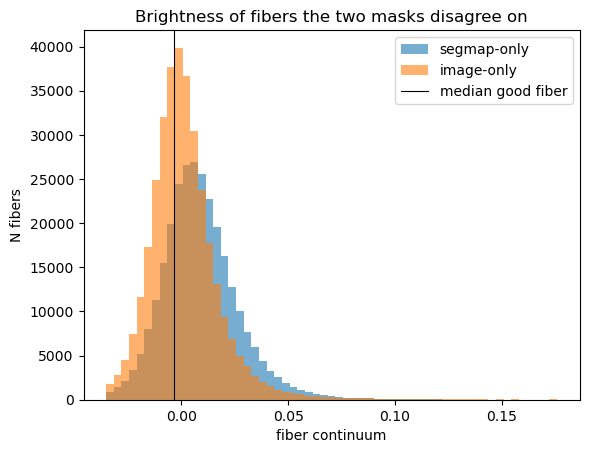

In [29]:
c = R["counts"]
print(f"fibers={c['n_fibers']:,}  both={c['both']:,}  "
      f"seg_only={c['seg_only']:,}  img_only={c['img_only']:,}")
for k in ("seg_only", "img_only", "both"):
    s = R[k]
    print(f"{k:<9} n={s['n']:>7}  cont_med={s['cont_med']:.3e}  "
          f"d_gal={s['d_gal_med']}  d_bright={s['d_bright_med']:.1f}\"  "
          f"near_bad={s['frac_near_bad']:.2f}")

# the decisive plot: brightness distribution of the disagreement fibers
fin = R["fin"]
seg_only = R["seg"] & ~R["img"] & fin
img_only = ~R["seg"] & R["img"] & fin
bins = np.linspace(np.nanpercentile(R["cont"][fin], 1),
                   np.nanpercentile(R["cont"][fin], 99), 60)
plt.hist(R["cont"][seg_only], bins, alpha=.6, label="segmap-only")
plt.hist(R["cont"][img_only], bins, alpha=.6, label="image-only")
plt.axvline(R["good_cont_med"], color="k", lw=.8, label="median good fiber")
plt.xlabel("fiber continuum"); plt.ylabel("N fibers"); plt.legend()
plt.title("Brightness of fibers the two masks disagree on"); plt.show()

In [43]:
# --- example usage ---
A = compare_masks_in_annulus(R, catalog["RA"], catalog["DEC"], vdfi['RA'], vdfi['DEC'])

In [44]:
print(f"annulus-eligible fibers: {A['n_annulus']:,}")
for k in ("both", "seg_only", "img_only", "neither"):
    print(f"  {k:<9} n={A[k]:>7}  cont_med={A.get(k+'_cont_med', float('nan')):.3e}")

annulus-eligible fibers: 98,350
  both      n=   4826  cont_med=4.357e-02
  seg_only  n=   6657  cont_med=6.497e-03
  img_only  n=   7781  cont_med=2.403e-05
  neither   n=  79086  cont_med=nan


In [70]:
# --- example usage ---
from astropy.cosmology import Planck18 as cosmo
Ap = compare_masks_in_aperture(R, catalog["RA"], catalog["DEC"], vdfi['RA'], vdfi['DEC'],
                               catalog["z"], cfg_new.bins, cosmo, bin_index=0)   # innermost bin
print(Ap)

{'n_aperture': 4216, 'both': 43, 'both_cont_med': 0.014027172699570656, 'seg_only': 169, 'seg_only_cont_med': 0.012373332865536213, 'img_only': 455, 'img_only_cont_med': 0.005953526124358177}


In [71]:
# # --- example usage ---
# from astropy.cosmology import Planck18 as cosmo
# Ap = compare_masks_in_aperture(R, catalog["RA"], catalog["DEC"], vdfi['RA'], vdfi['DEC'],
#                                catalog["z"], cfg_new.bins, cosmo, bin_index=1)
# print(Ap)

In [72]:
# --- example usage ---
asym = mask_offset_asymmetry(R, A, Ap)   # A = annulus dict, Ap = aperture dict from before
print(f"annulus  seg-pct net flux: {asym['annulus_net_flux_diff']:.3e}")
print(f"aperture seg-pct net flux: {asym['aperture_net_flux_diff']:.3e}")
print(f"asymmetry (=net subtraction offset): {asym['asymmetry']:.3e}")

annulus  seg-pct net flux: -4.379e-04
aperture seg-pct net flux: 1.465e-04
asymmetry (=net subtraction offset): 5.844e-04


# Continuum Features Persisting after Segmap

In [173]:
def stack_unmasked_bright_tail(R, spectra, ra, dec, gal_RA, gal_DEC,
                               top_frac=0.005, inner_as=55.0, outer_as=65.0, step=1):
    """
    Stack the brightest fibers segmap KEEPS, among background-eligible (annulus)
    fibers. Flat noise -> segmap's un-masked tail is harmless. Real continuum/lines
    -> contamination leaking through the mask; a tactical bake-time fix worth making.
    Returns the median stacked spectrum + the fibers' continuum levels + indices.
    """
    ra, dec = np.asarray(ra,float).ravel(), np.asarray(dec,float).ravel()
    fin = R["fin"]
    d_gal = _nn_arcsec(ra[fin], dec[fin], gal_RA, gal_DEC)
    in_ann = np.zeros(fin.size, bool)
    in_ann[fin] = (d_gal >= inner_as) & (d_gal <= outer_as)

    kept = (~R["seg"]) & in_ann          # segmap keeps it AND it's background-eligible
    cont = R["cont"]
    idx = np.flatnonzero(kept)
    if idx.size == 0:
        return {"n": 0}
    thresh = np.nanpercentile(cont[idx], 100 * (1 - top_frac))
    tail = idx[cont[idx] >= thresh]      # the brightest survivors

    # stack their spectra (flatten nexp*nfib -> map back to (exp, fib))
    nexp, nfib = spectra.shape[:2]
    ei, fi = np.unravel_index(tail, (nexp, nfib))
    rows = np.stack([spectra[e, f, ::step] for e, f in zip(ei, fi)])
    med = np.nanmedian(rows, axis=0)
    return {"n": tail.size, "thresh": float(thresh), "stack": med,
            "cont_tail": cont[tail], "tail_idx": tail}

def classify_bright_tail(S, spectra_shape, ra, dec, R, sep_as=2.0):
    """
    Are the bright unmasked fibers INSTRUMENTAL (bad fibers) or ASTROPHYSICAL
    (sources the image mask missed)?
      fiber_recurrence : mean # exposures each tail fiber-index appears in.
          >> null -> a fixed set of bad fibers repeating exposure to exposure.
      sky_clustering   : fraction of tail fibers within sep_as of ANOTHER tail
          fiber from a DIFFERENT exposure -> same sky spot -> a real source.
    Image-plane masks (segmap AND percentile) cannot see the instrumental kind.
    """
    nexp, nfib = spectra_shape[:2]
    tail = S["tail_idx"]
    ei, fi = np.unravel_index(tail, (nexp, nfib))

    # 1. recurrence in FIBER space
    _, counts = np.unique(fi, return_counts=True)
    fiber_recurrence = float(counts.mean())
    null = tail.size / nfib                      # if fibers were random

    # 2. recurrence in SKY space (cross-exposure)
    ra_t = np.asarray(ra, float).ravel()[tail]
    dec_t = np.asarray(dec, float).ravel()[tail]
    from scipy.spatial import cKDTree
    cosd = np.cos(np.radians(np.nanmedian(dec_t)))
    tree = cKDTree(np.column_stack([ra_t * cosd, dec_t]))
    pairs = tree.query_ball_point(np.column_stack([ra_t * cosd, dec_t]),
                                  r=sep_as / 3600.0)
    diff_exp = [any(ei[j] != ei[i] for j in p if j != i) for i, p in enumerate(pairs)]
    return {"n_tail": int(tail.size),
            "fiber_recurrence": fiber_recurrence, "null_recurrence": float(null),
            "recurrence_ratio": fiber_recurrence / null if null else np.nan,
            "sky_clustering": float(np.mean(diff_exp))}

def fiber_vs_sky_attribution(S, spectra_shape, ra, dec, R, cell_as=3.0, n_null=200, seed=0):
    """
    Does the bright tail's flux follow the FIBER or the SKY?
      fiber_var_frac : variance of tail-fiber continuum explained by fiber index
      sky_var_frac   : ...explained by sky cell (cell_as grid)
      sky_clust_xfib : sky clustering counting ONLY pairs with DIFFERENT fiber index
                       (removes the dither self-match that inflated the old metric)
      recurrence_z   : recurrence vs a permutation null (not the broken 1/null ratio)
    fiber >> sky  -> instrumental bad fibers (invisible to any image-plane mask)
    sky >> fiber  -> real sources below the CFHT detection threshold
    """
    rng = np.random.default_rng(seed)
    nexp, nfib = spectra_shape[:2]
    tail = S["tail_idx"]
    ei, fi = np.unravel_index(tail, (nexp, nfib))
    cont = R["cont"][tail]
    ra_t = np.asarray(ra, float).ravel()[tail]
    dec_t = np.asarray(dec, float).ravel()[tail]

    def var_frac(groups, y):
        tot = np.nanvar(y)
        if tot == 0: return np.nan
        within = np.nansum([np.nanvar(y[groups == g]) * (groups == g).sum()
                            for g in np.unique(groups)]) / len(y)
        return float(1.0 - within / tot)            # between-group variance fraction

    cosd = np.cos(np.radians(np.nanmedian(dec_t)))
    cell = (np.round(ra_t * cosd * 3600 / cell_as).astype(int) * 100000
            + np.round(dec_t * 3600 / cell_as).astype(int))

    # sky clustering, cross-fiber only
    from scipy.spatial import cKDTree
    tree = cKDTree(np.column_stack([ra_t * cosd, dec_t]))
    nb = tree.query_ball_point(np.column_stack([ra_t * cosd, dec_t]), r=2.0 / 3600.0)
    xfib = [any((fi[j] != fi[i]) and (ei[j] != ei[i]) for j in p if j != i)
            for i, p in enumerate(nb)]

    # recurrence vs permutation null
    obs = np.unique(fi, return_counts=True)[1].mean()
    null = [np.unique(rng.integers(0, nfib, tail.size), return_counts=True)[1].mean()
            for _ in range(n_null)]
    return {"fiber_var_frac": var_frac(fi, cont), "sky_var_frac": var_frac(cell, cont),
            "sky_clust_xfib": float(np.mean(xfib)),
            "recurrence_obs": float(obs), "recurrence_null": float(np.mean(null)),
            "recurrence_z": float((obs - np.mean(null)) / (np.std(null) + 1e-12))}


def stack_unmasked_tail(R, spectra, ra, dec, gal_RA, gal_DEC,
                         tail='bright', top_frac=0.005,
                         inner_as=55.0, outer_as=65.0, step=1):
    """
    Stack the brightest OR dimmest fibers segmap KEEPS, among background-eligible
    (annulus) fibers.
      tail='bright' -> original behavior: brightest top_frac survivors.
      tail='dim'    -> faintest top_frac survivors (unexamined so far --
                       candidate for very dim/noisy leakage through the mask).
      tail='both'   -> returns {'bright': {...}, 'dim': {...}}, NOT combined.
    Flat noise in a tail -> harmless. Real continuum/lines (bright) or excess
    scatter (dim) -> contamination leaking through the mask.
    """
    if tail not in ('bright', 'dim', 'both'):
        raise ValueError("tail must be 'bright', 'dim', or 'both'")

    ra, dec = np.asarray(ra, float).ravel(), np.asarray(dec, float).ravel()
    fin = R["fin"]
    d_gal = _nn_arcsec(ra[fin], dec[fin], gal_RA, gal_DEC)
    in_ann = np.zeros(fin.size, bool)
    in_ann[fin] = (d_gal >= inner_as) & (d_gal <= outer_as)

    kept = (~R["seg"]) & in_ann          # segmap keeps it AND it's background-eligible
    cont = R["cont"]
    idx = np.flatnonzero(kept)
    if idx.size == 0:
        return {"n": 0}

    nexp, nfib = spectra.shape[:2]

    def _one_tail(direction):
        if direction == 'bright':
            thresh = np.nanpercentile(cont[idx], 100 * (1 - top_frac))
            sel = idx[cont[idx] >= thresh]
        else:  # 'dim'
            thresh = np.nanpercentile(cont[idx], 100 * top_frac)
            sel = idx[cont[idx] <= thresh]
        if sel.size == 0:
            return {"n": 0, "thresh": float(thresh)}
        ei, fi = np.unravel_index(sel, (nexp, nfib))
        rows = np.stack([spectra[e, f, ::step] for e, f in zip(ei, fi)])
        med = np.nanmedian(rows, axis=0)
        return {"n": sel.size, "thresh": float(thresh), "stack": med,
                "cont_tail": cont[sel], "tail_idx": sel}

    if tail == 'both':
        return {"bright": _one_tail('bright'), "dim": _one_tail('dim')}
    return _one_tail(tail)

In [201]:
wave_raw = vdfi['wave']

# example usage in notebook
S005 = stack_unmasked_tail(R, vdfi['spectra'], vdfi['RA'], vdfi['DEC'],
                        catalog["RA"], catalog["DEC"], tail='both', top_frac=0.005,
                        inner_as=10.0, outer_as=100.0,)
print("bright tail n:", S005['bright']['n'], "  dim tail n:", S005['dim']['n'])

# example usage in notebook
S01 = stack_unmasked_tail(R, vdfi['spectra'], vdfi['RA'], vdfi['DEC'],
                        catalog["RA"], catalog["DEC"], tail='both', top_frac=0.01,
                        inner_as=10.0, outer_as=100.0,)
print("bright tail n:", S01['bright']['n'], "  dim tail n:", S01['dim']['n'])

bright tail n: 7744   dim tail n: 7744
bright tail n: 15487   dim tail n: 15487


In [191]:
# example usage in notebook
S05 = stack_unmasked_tail(R, vdfi['spectra'], vdfi['RA'], vdfi['DEC'],
                        catalog["RA"], catalog["DEC"], tail='both', top_frac=0.05,
                        inner_as=10.0, outer_as=100.0,)
print("bright tail n:", S05['bright']['n'], "  dim tail n:", S05['dim']['n'])

bright tail n: 77435   dim tail n: 77435


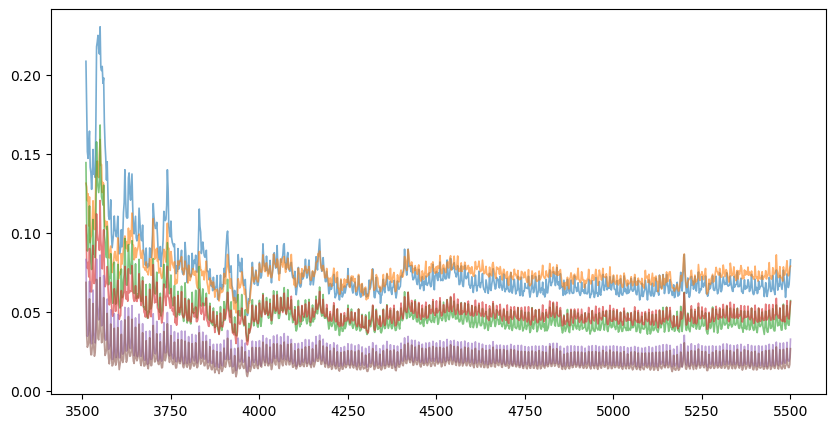

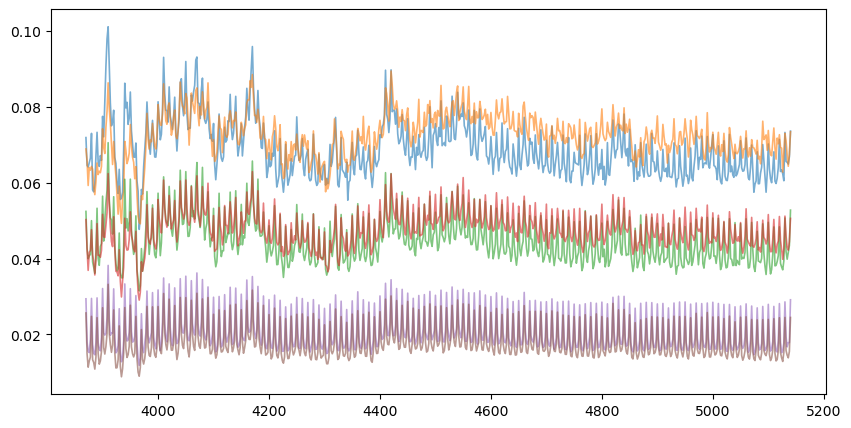

In [203]:
plt.figure(figsize=(10, 5))
plt.plot(wave_raw[20:-20],-1*S005['dim']["stack"][20:-20],
        lw=1.2,alpha=0.6,
        label='bright')
plt.plot(wave_raw[20:-20],S005['bright']["stack"][20:-20],
        lw=1.2,alpha=0.6,
        label='bright')

plt.plot(wave_raw[20:-20],-1*S01['dim']["stack"][20:-20],
        lw=1.2,alpha=0.6,
        label='bright')
plt.plot(wave_raw[20:-20],S01['bright']["stack"][20:-20],
        lw=1.2,alpha=0.6,
        label='bright')

plt.plot(wave_raw[20:-20],-1*S05['dim']["stack"][20:-20],
        lw=1.2,alpha=0.6,
        label='bright')
plt.plot(wave_raw[20:-20],S05['bright']["stack"][20:-20],
        lw=1.2,alpha=0.6,
        label='bright')


plt.figure(figsize=(10, 5))
plt.plot(wave_raw[200:-200],-1*S005['dim']["stack"][200:-200],
        lw=1.2,alpha=0.6,
        label='bright')
plt.plot(wave_raw[200:-200],S005['bright']["stack"][200:-200],
        lw=1.2,alpha=0.6,
        label='bright')

plt.plot(wave_raw[200:-200],-1*S01['dim']["stack"][200:-200],
        lw=1.2,alpha=0.6,
        label='bright')
plt.plot(wave_raw[200:-200],S01['bright']["stack"][200:-200],
        lw=1.2,alpha=0.6,
        label='bright')

plt.plot(wave_raw[200:-200],-1*S05['dim']["stack"][200:-200],
        lw=1.2,alpha=0.6,
        label='bright')
plt.plot(wave_raw[200:-200],S05['bright']["stack"][200:-200],
        lw=1.2,alpha=0.6,
        label='bright')

In [147]:
percentile = 0.005


S1 = stack_unmasked_bright_tail(R, vdfi['spectra'], vdfi['RA'], vdfi['DEC'],
                               catalog["RA"], catalog["DEC"], top_frac=percentile,
                               inner_as=10.0, outer_as=20.0, step=1)

S2 = stack_unmasked_bright_tail(R, vdfi['spectra'], vdfi['RA'], vdfi['DEC'],
                               catalog["RA"], catalog["DEC"], top_frac=percentile,
                               inner_as=20.0, outer_as=35.0, step=1)

S3 = stack_unmasked_bright_tail(R, vdfi['spectra'], vdfi['RA'], vdfi['DEC'],
                               catalog["RA"], catalog["DEC"], top_frac=percentile,
                               inner_as=35.0, outer_as=60.0, step=1)

S4 = stack_unmasked_bright_tail(R, vdfi['spectra'], vdfi['RA'], vdfi['DEC'],
                               catalog["RA"], catalog["DEC"], top_frac=percentile,
                               inner_as=60.0, outer_as=100.0, step=1)

S5 = stack_unmasked_bright_tail(R, vdfi['spectra'], vdfi['RA'], vdfi['DEC'],
                               catalog["RA"], catalog["DEC"], top_frac=percentile,
                               inner_as=100.0, outer_as=150.0, step=1)

S6 = stack_unmasked_bright_tail(R, vdfi['spectra'], vdfi['RA'], vdfi['DEC'],
                               catalog["RA"], catalog["DEC"], top_frac=percentile,
                               inner_as=150.0, outer_as=200.0, step=1)

In [171]:
print(f"stacked {S1['n']} unmasked bright annulus fibers (cont >= {S1['thresh']:.5e})")
print(f"stacked {S2['n']} unmasked bright annulus fibers (cont >= {S2['thresh']:.5e})")
print(f"stacked {S3['n']} unmasked bright annulus fibers (cont >= {S3['thresh']:.5e})")
print(f"stacked {S4['n']} unmasked bright annulus fibers (cont >= {S4['thresh']:.5e})")
print(f"stacked {S5['n']} unmasked bright annulus fibers (cont >= {S5['thresh']:.5e})")
print(f"stacked {S6['n']} unmasked bright annulus fibers (cont >= {S6['thresh']:.5e})")

stacked 4574 unmasked bright annulus fibers (cont >= 3.01456e-02)
stacked 4977 unmasked bright annulus fibers (cont >= 3.14480e-02)
stacked 3094 unmasked bright annulus fibers (cont >= 3.43601e-02)
stacked 2844 unmasked bright annulus fibers (cont >= 3.27242e-02)
stacked 3111 unmasked bright annulus fibers (cont >= 3.03821e-02)
stacked 2858 unmasked bright annulus fibers (cont >= 3.06563e-02)


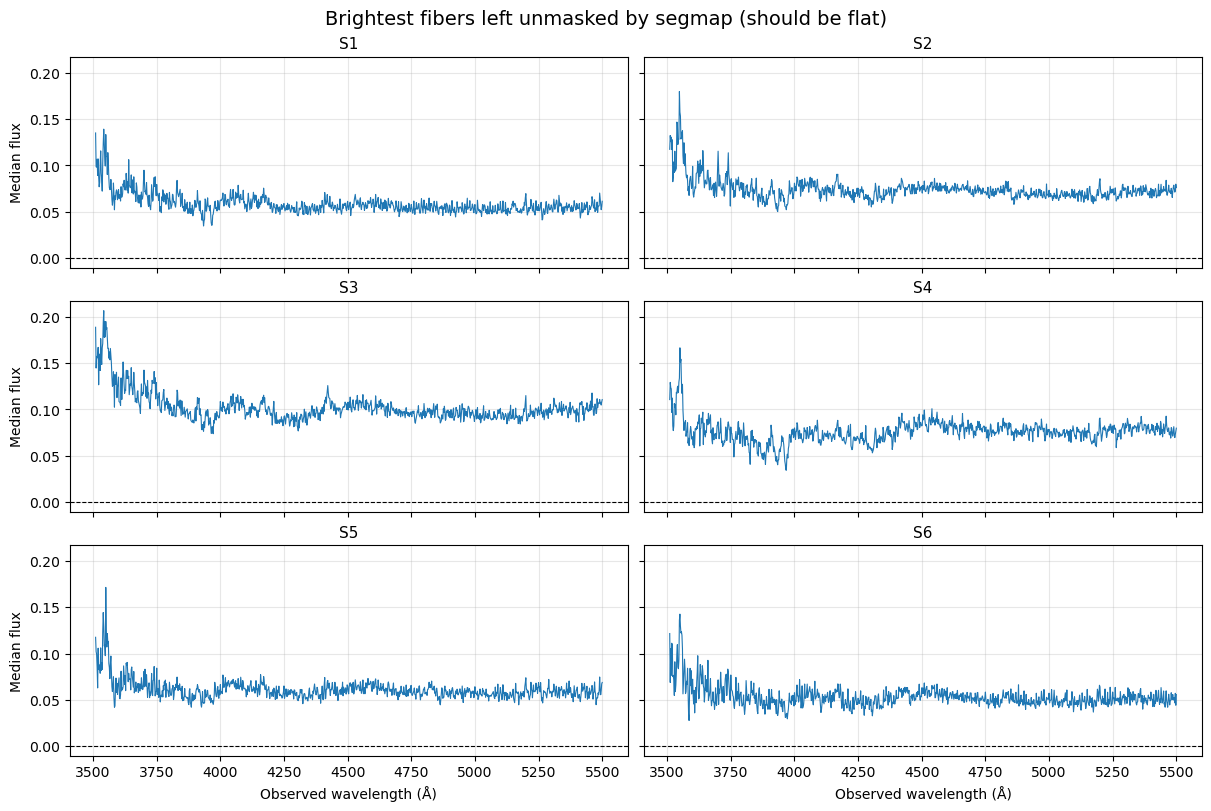

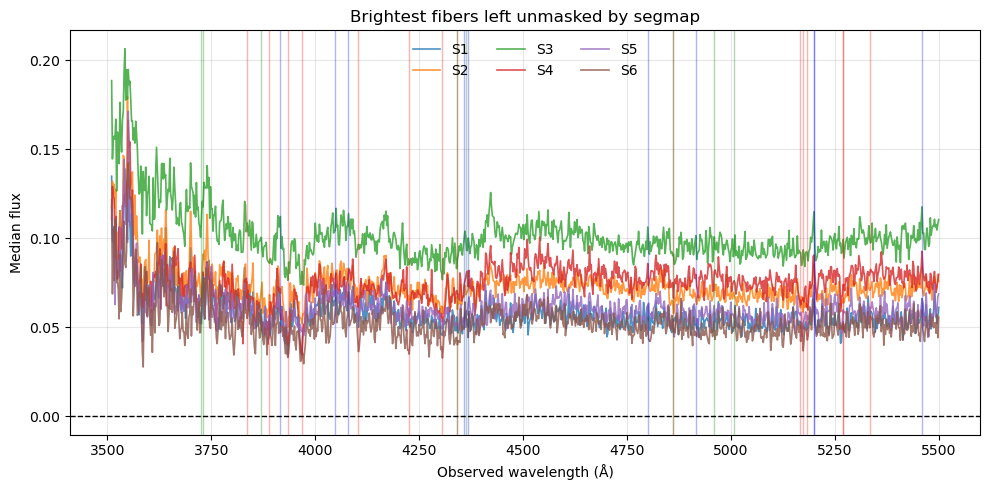

In [152]:
wave = vdfi['wave'][20:-20]
stacks = [S1, S2, S3, S4, S5, S6]
titles = [
    "S1", "S2", "S3",
    "S4", "S5", "S6"
]

fig, axes = plt.subplots(
    3, 2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for ax, stack, title in zip(axes.flat, stacks, titles):
    ax.plot(wave, stack["stack"][20:-20], lw=0.8)
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3)

# Label only the outer axes
for ax in axes[-1]:
    ax.set_xlabel("Observed wavelength (Å)")

for ax in axes[:, 0]:
    ax.set_ylabel("Median flux")

fig.suptitle(
    "Brightest fibers left unmasked by segmap (should be flat)",
    fontsize=14
)

plt.show()

# ALL ON ONE
wave = vdfi["wave"][20:-20]
stacks = [S1, S2, S3, S4, S5, S6]
labels = ["S1", "S2", "S3", "S4", "S5", "S6"]

sky_lines = np.array([
    3914.0,   # N2+
    4046.56,  # Hg I
    4077.84,  # Hg I
    4358.33,  # Hg I
    4368.25,  # O I (weak)
    4799.91,  # N I
    4916.07,  # Hg I
    5199.35,  # N I
    5200.26,  # N I
    5460.74,  # Hg I
])

major_stellar = np.array([
    3933.66,  # Ca II K
    3968.47,  # Ca II H
    4101.74,  # Hδ
    4304.4,   # G band
    4340.47,  # Hγ
    4861.33,  # Hβ
    5175.0,   # Mg b triplet (center)
])

galaxy_emission = np.array([
    3726.03,  # [O II]
    3728.82,  # [O II]
    3868.76,  # [Ne III]
    4340.47,  # Hγ
    4363.21,  # [O III]
    4861.33,  # Hβ
    4958.91,  # [O III]
    5006.84,  # [O III]
])

plt.figure(figsize=(10, 5))

for stack, label in zip(stacks, labels):
    plt.plot(
        wave,
        stack["stack"][20:-20],
        lw=1.2,
        alpha=0.8,
        label=label
    )

for SL in sky_lines:
    plt.axvline(SL, lw=1, c='b', alpha=0.3)
for SF in stellar_features:
    plt.axvline(SF, lw=1, c='r', alpha=0.3)
for GE in galaxy_emission:
    plt.axvline(GE, lw=1, c='g', alpha=0.3)

plt.axhline(0, color="k", ls="--", lw=1)
plt.xlabel("Observed wavelength (Å)")
plt.ylabel("Median flux")
plt.title("Brightest fibers left unmasked by segmap")
plt.legend(ncol=3, frameon=False)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [153]:
A1 = fiber_vs_sky_attribution(S1, vdfi['spectra'].shape, vdfi['RA'], vdfi['DEC'], R)
print(f"variance explained by FIBER index : {A1['fiber_var_frac']:.3f}")
print(f"variance explained by SKY cell    : {A1['sky_var_frac']:.3f}")
print(f"cross-fiber sky clustering        : {A1['sky_clust_xfib']:.2f}  (dither-corrected)")
print(f"recurrence {A1['recurrence_obs']:.2f} vs permuted null "
      f"{A1['recurrence_null']:.2f}  (z = {A1['recurrence_z']:.1f})")
A2 = fiber_vs_sky_attribution(S2, vdfi['spectra'].shape, vdfi['RA'], vdfi['DEC'], R)
print(f"variance explained by FIBER index : {A2['fiber_var_frac']:.3f}")
print(f"variance explained by SKY cell    : {A2['sky_var_frac']:.3f}")
print(f"cross-fiber sky clustering        : {A2['sky_clust_xfib']:.2f}  (dither-corrected)")
print(f"recurrence {A2['recurrence_obs']:.2f} vs permuted null "
      f"{A2['recurrence_null']:.2f}  (z = {A2['recurrence_z']:.1f})")
A3 = fiber_vs_sky_attribution(S3, vdfi['spectra'].shape, vdfi['RA'], vdfi['DEC'], R)
print(f"variance explained by FIBER index : {A3['fiber_var_frac']:.3f}")
print(f"variance explained by SKY cell    : {A3['sky_var_frac']:.3f}")
print(f"cross-fiber sky clustering        : {A3['sky_clust_xfib']:.2f}  (dither-corrected)")
print(f"recurrence {A3['recurrence_obs']:.2f} vs permuted null "
      f"{A3['recurrence_null']:.2f}  (z = {A3['recurrence_z']:.1f})")
A4 = fiber_vs_sky_attribution(S4, vdfi['spectra'].shape, vdfi['RA'], vdfi['DEC'], R)
print(f"variance explained by FIBER index : {A4['fiber_var_frac']:.3f}")
print(f"variance explained by SKY cell    : {A4['sky_var_frac']:.3f}")
print(f"cross-fiber sky clustering        : {A4['sky_clust_xfib']:.2f}  (dither-corrected)")
print(f"recurrence {A4['recurrence_obs']:.2f} vs permuted null "
      f"{A4['recurrence_null']:.2f}  (z = {A4['recurrence_z']:.1f})")
A5 = fiber_vs_sky_attribution(S5, vdfi['spectra'].shape, vdfi['RA'], vdfi['DEC'], R)
print(f"variance explained by FIBER index : {A5['fiber_var_frac']:.3f}")
print(f"variance explained by SKY cell    : {A5['sky_var_frac']:.3f}")
print(f"cross-fiber sky clustering        : {A5['sky_clust_xfib']:.2f}  (dither-corrected)")
print(f"recurrence {A5['recurrence_obs']:.2f} vs permuted null "
      f"{A5['recurrence_null']:.2f}  (z = {A5['recurrence_z']:.1f})")
A6 = fiber_vs_sky_attribution(S6, vdfi['spectra'].shape, vdfi['RA'], vdfi['DEC'], R)
print(f"variance explained by FIBER index : {A6['fiber_var_frac']:.3f}")
print(f"variance explained by SKY cell    : {A6['sky_var_frac']:.3f}")
print(f"cross-fiber sky clustering        : {A6['sky_clust_xfib']:.2f}  (dither-corrected)")
print(f"recurrence {A6['recurrence_obs']:.2f} vs permuted null "
      f"{A6['recurrence_null']:.2f}  (z = {A6['recurrence_z']:.1f})")

variance explained by FIBER index : 0.949
variance explained by SKY cell    : 0.921
cross-fiber sky clustering        : 0.48  (dither-corrected)
recurrence 1.33 vs permuted null 1.03  (z = 76.5)
variance explained by FIBER index : 0.844
variance explained by SKY cell    : 0.752
cross-fiber sky clustering        : 0.58  (dither-corrected)
recurrence 1.45 vs permuted null 1.04  (z = 98.9)
variance explained by FIBER index : 0.868
variance explained by SKY cell    : 0.698
cross-fiber sky clustering        : 0.56  (dither-corrected)
recurrence 1.51 vs permuted null 1.02  (z = 127.7)
variance explained by FIBER index : 0.905
variance explained by SKY cell    : 0.377
cross-fiber sky clustering        : 0.62  (dither-corrected)
recurrence 1.51 vs permuted null 1.02  (z = 137.3)
variance explained by FIBER index : 0.694
variance explained by SKY cell    : 0.902
cross-fiber sky clustering        : 0.46  (dither-corrected)
recurrence 1.39 vs permuted null 1.02  (z = 99.9)
variance explained by F

# Fiber Oscillations - Early Development

In [72]:
def fiber_highpass(spec, trend_pix=31):
    """Smooth-trend-removed residual per fiber. spec: (nfib,nwave) or (nwave,)."""
    spec = np.atleast_2d(np.asarray(spec, float))
    out = np.full_like(spec, np.nan)
    for i in range(spec.shape[0]):
        y = spec[i]; g = np.isfinite(y)
        if g.sum() < trend_pix:
            continue
        yf = np.interp(np.arange(y.size), np.flatnonzero(g), y[g])
        out[i] = y - median_filter(yf, size=trend_pix, mode="nearest")
    return out

def oscillation_report(fiber_spectra, wave, trend_pix=31):
    """
    shared_frac = RMS(mean over fibers) / mean(per-fiber RMS), in [0,1]:
        ~1 -> oscillation has SHARED phase (a template/basis can remove it)
        ~0 -> random phase (per-fiber; no common template)
    blue_red   -> red-half RMS / blue-half RMS (>1 = grows toward the red edge)
    mean_power -> average |FFT|; a peak marks a common oscillation frequency
    """
    hp = fiber_highpass(fiber_spectra, trend_pix)
    cont = np.nanmedian(np.atleast_2d(fiber_spectra), axis=1)
    n = hp.shape[1]; half = n // 2
    rms  = np.sqrt(np.nanmean(hp**2, axis=1))
    blue = np.sqrt(np.nanmean(hp[:, :half]**2, axis=1))
    red  = np.sqrt(np.nanmean(hp[:, half:]**2, axis=1))
    coherent   = np.sqrt(np.nanmean(np.nanmean(hp, axis=0)**2))
    incoherent = np.nanmean(rms)
    F = np.abs(np.fft.rfft(np.nan_to_num(hp), axis=1))
    return {"rms": rms, "cont": cont, "blue_red": red / blue,
            "shared_frac": float(coherent / incoherent) if incoherent else np.nan,
            "mean_power": np.nanmean(F, axis=0),
            "freq": np.fft.rfftfreq(n, d=1.0), "hp": hp}

In [114]:
wave = mega_new.wave

In [117]:
for i in range(mega_old.spec.shape[1]):
    print(f"Working on radial bin #{i+1}")
    osc = oscillation_report(mega_new.spec[:, i, :], wave)
    
    print(f"shared_frac = {osc['shared_frac']:.2f}  "
          f"(->1 templatable, ->0 per-fiber random)")
    print(f"amplitude-vs-brightness r = "
          f"{np.corrcoef(osc['cont'], osc['rms'])[0,1]:.2f}")
    print(f"median red/blue RMS ratio = {np.nanmedian(osc['blue_red']):.2f}  "
          f"(>1 = worse toward red edge)")

Working on radial bin #1


/tmp/ipykernel_10455/3932582347.py:24: RuntimeWarning: Mean of empty slice
  rms  = np.sqrt(np.nanmean(hp**2, axis=1))
/tmp/ipykernel_10455/3932582347.py:25: RuntimeWarning: Mean of empty slice
  blue = np.sqrt(np.nanmean(hp[:, :half]**2, axis=1))
/tmp/ipykernel_10455/3932582347.py:26: RuntimeWarning: Mean of empty slice
  red  = np.sqrt(np.nanmean(hp[:, half:]**2, axis=1))


shared_frac = 0.10  (->1 templatable, ->0 per-fiber random)
amplitude-vs-brightness r = nan
median red/blue RMS ratio = 0.52  (>1 = worse toward red edge)
Working on radial bin #2
shared_frac = 0.13  (->1 templatable, ->0 per-fiber random)
amplitude-vs-brightness r = nan
median red/blue RMS ratio = 0.50  (>1 = worse toward red edge)
Working on radial bin #3
shared_frac = 0.11  (->1 templatable, ->0 per-fiber random)
amplitude-vs-brightness r = nan
median red/blue RMS ratio = 0.49  (>1 = worse toward red edge)
Working on radial bin #4
shared_frac = 0.14  (->1 templatable, ->0 per-fiber random)
amplitude-vs-brightness r = nan
median red/blue RMS ratio = 0.47  (>1 = worse toward red edge)
Working on radial bin #5
shared_frac = 0.09  (->1 templatable, ->0 per-fiber random)
amplitude-vs-brightness r = nan
median red/blue RMS ratio = 0.43  (>1 = worse toward red edge)
Working on radial bin #6
shared_frac = 0.10  (->1 templatable, ->0 per-fiber random)
amplitude-vs-brightness r = nan
median r

shared_frac = 0.21  (->1 templatable, ->0 per-fiber random)
amplitude-vs-brightness r = -0.07
median red/blue RMS ratio = 0.33  (>1 = worse toward red edge)


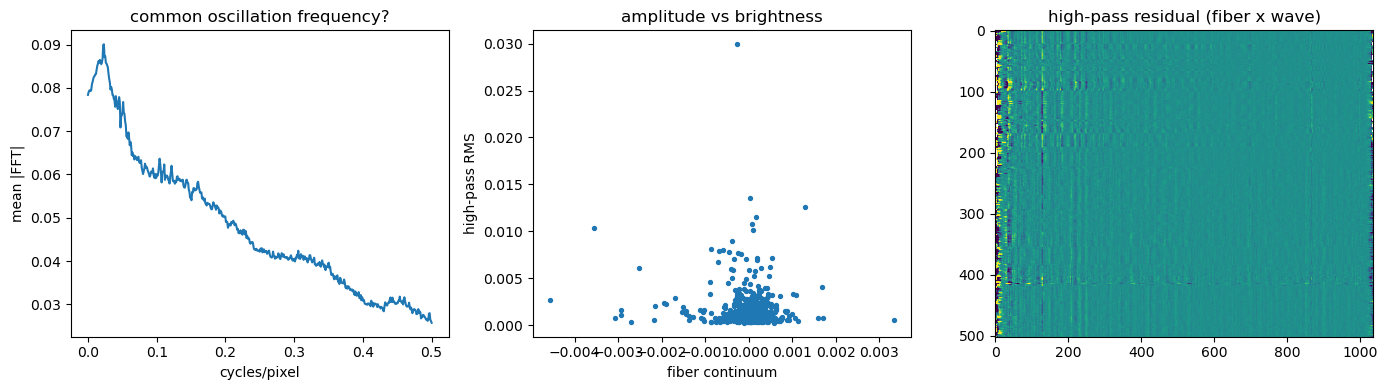

In [112]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(osc["freq"], osc["mean_power"]); ax[0].set_xlabel("cycles/pixel")
ax[0].set_ylabel("mean |FFT|"); ax[0].set_title("common oscillation frequency?")
ax[1].scatter(osc["cont"], osc["rms"], s=8); ax[1].set_xlabel("fiber continuum")
ax[1].set_ylabel("high-pass RMS"); ax[1].set_title("amplitude vs brightness")
ax[2].imshow(osc["hp"], aspect="auto", vmin=-np.nanstd(osc["hp"]),
             vmax=np.nanstd(osc["hp"])); ax[2].set_title("high-pass residual (fiber x wave)")
plt.tight_layout(); plt.show()